# Comparison between 3 religious stacks

In [2]:
import pandas as pd 
from IPython.display import display, Markdown, HTML
import matplotlib.pyplot as plt
from scipy import stats
import bs4
import xml.etree.ElementTree as ET
import bs4
import numpy as np
import math

In [3]:
# Format date
def format_date(date_in, format="%d %B %Y"):
    return date_in.strftime(format)

# Format a timedelta to years and days
def format_timedelta(td):
    years = td.days // 365
    days = td.days % 365
    
    year_str = f"{years} year{'s' if years != 1 else ''}"
    day_str = f"{days} day{'s' if days != 1 else ''}"
    
    return f"{year_str}, {day_str}"

In [4]:
# extract xml files from 7z format. check if the files exist first. 

import py7zr
import os

extract_dir = 'data'

# only extract posts and comments xml
NEEDED_FILES = {'Posts.xml', 'Comments.xml'}

def extract_and_prefix(stackname):
    prefix = stackname + '_'
    # if we already have all needed xml files with that prefix, skip
    existing = {f.removeprefix(prefix) for f in os.listdir(extract_dir)
                if f.startswith(prefix) and f.endswith('.xml')}
    if NEEDED_FILES.issubset(existing):
        print(f"{stackname} files already present; skipping.")
        return

    archive = os.path.join(extract_dir, f"{stackname}.stackexchange.com.7z")
    print(f"Extracting {stackname}…")
    with py7zr.SevenZipFile(archive, mode='r') as z:
        z.extract(path=extract_dir, targets=list(NEEDED_FILES))

    # rename extracted files to add prefix
    for filename in NEEDED_FILES:
        old_path = os.path.join(extract_dir, filename)
        new_path = os.path.join(extract_dir, prefix + filename)
        if os.path.exists(old_path):
            os.rename(old_path, new_path)

for stack in ('buddhism', 'christianity', 'islam'):
    extract_and_prefix(stack)


buddhism files already present; skipping.
christianity files already present; skipping.
islam files already present; skipping.


In [5]:
import xml.etree.ElementTree as ET
import bs4
import numpy as np
import math

# built the three stacks into a dictionary, the analysis will loop through the stacks. 
STACKS = ['buddhism', 'christianity', 'islam']
COLORS = {'buddhism': '#e07b00', 'christianity': '#1a6ea8', 'islam': '#2a9d5c'}
LABELS = {'buddhism': 'Buddhism', 'christianity': 'Christianity', 'islam': 'Islam'}

def parse_xml_posts(path):
    tree = ET.parse(path)
    root = tree.getroot()
    data = [row.attrib for row in root.findall('row')]
    df = pd.DataFrame(data)
    df['CreationDate'] = pd.to_datetime(df['CreationDate'])
    if 'LastActivityDate' in df.columns:
        df['LastActivityDate'] = pd.to_datetime(df['LastActivityDate'])
    if 'LastEditDate' in df.columns:
        df['LastEditDate'] = pd.to_datetime(df['LastEditDate'], errors='coerce')
    if 'ClosedDate' in df.columns:
        df['ClosedDate'] = pd.to_datetime(df['ClosedDate'], errors='coerce')
    if 'Score' in df.columns:
        df['Score'] = pd.to_numeric(df['Score'], errors='coerce').fillna(0).astype(int)
    if 'AnswerCount' in df.columns:
        df['AnswerCount'] = pd.to_numeric(df['AnswerCount'], errors='coerce')
    if 'CommentCount' in df.columns:
        df['CommentCount'] = pd.to_numeric(df['CommentCount'], errors='coerce').fillna(0).astype(int)
    if 'ViewCount' in df.columns:
        df['ViewCount'] = pd.to_numeric(df['ViewCount'], errors='coerce')
    def extract_text(html):
        try:
            return bs4.BeautifulSoup(html, 'html.parser').get_text(separator=' ')
        except:
            return ''
    def extract_urls(html):
        try:
            soup = bs4.BeautifulSoup(html, 'html.parser')
            return [a['href'] for a in soup.find_all('a', href=True)]
        except:
            return []
    if 'Body' in df.columns:
        df['BodyText'] = df['Body'].apply(extract_text)
        df['BodyURLs'] = df['Body'].apply(extract_urls)
    else:
        df['BodyText'] = ''
        df['BodyURLs'] = [[] for _ in range(len(df))]
    return df

def parse_xml_comments(path):
    tree = ET.parse(path)
    root = tree.getroot()
    data = [row.attrib for row in root.findall('row')]
    df = pd.DataFrame(data)
    df['CreationDate'] = pd.to_datetime(df['CreationDate'])
    return df

stacks = {}
for name in STACKS:
    print(f'Loading {name}...')
    s_df = parse_xml_posts(f'data/{name}_Posts.xml')
    p_df = s_df[s_df['PostTypeId'].isin(['1','2'])].copy()
    c_df = parse_xml_comments(f'data/{name}_Comments.xml')
    stacks[name] = {'stack_df': s_df, 'post_df': p_df, 'comments_df': c_df}
    print(f'  {len(s_df)} posts, {len(c_df)} comments')
print('All stacks loaded.')


Loading buddhism...
  37572 posts, 47063 comments
Loading christianity...
  56950 posts, 136900 comments
Loading islam...
  38592 posts, 46814 comments
All stacks loaded.


# Comparative Analysis: Buddhism, Christianity, and Islam Stack Exchanges

The following sections repeat each analysis across the three religion-themed Stack Exchanges and present side-by-side comparisons where possible.

In [6]:
rows = []
for name in STACKS:
    sd = stacks[name]['stack_df']
    cd = stacks[name]['comments_df']
    first_q = sd['CreationDate'].min()
    last_act = sd['LastActivityDate'].max() if 'LastActivityDate' in sd.columns else sd['CreationDate'].max()
    time_range = last_act - first_q
    first_row = sd.loc[sd['CreationDate'].idxmin()]
    questions = sd[sd['PostTypeId'] == '1']
    most_ans_row = questions.loc[questions['AnswerCount'].idxmax()]
    highest_score_row = sd.loc[sd['Score'].idxmax()]
    rows.append({
        'Stack': LABELS[name],
        'First post': format_date(first_q),
        'Last activity': format_date(last_act),
        'Span': format_timedelta(time_range),
        'Total posts': len(sd),
        'Total comments': len(cd),
        'Most answers': int(most_ans_row['AnswerCount']),
        'Most-answered title': most_ans_row.get('Title', 'N/A'),
        'Highest score': int(highest_score_row['Score']),
        'Highest-score title': highest_score_row.get('Title', 'N/A'),
    })
    md = (f"### {LABELS[name]}\n"
          f"- **First post:** {format_date(first_q)} | **Last activity:** {format_date(last_act)} | **Span:** {format_timedelta(time_range)}\n"
          f"- **Total posts:** {len(sd):,} | **Total comments:** {len(cd):,}\n"
          f"- **Most-answered post** ({int(most_ans_row['AnswerCount'])} answers): *{most_ans_row.get('Title','N/A')}*\n"
          f"- **Highest-scored post** (score {int(highest_score_row['Score'])}): *{highest_score_row.get('Title','N/A')}*\n")
    display(Markdown(md))

header = '| Metric | ' + ' | '.join(LABELS[n] for n in STACKS) + ' |'
sep    = '|-' + '|-' * len(STACKS) + '|'
metrics = [
    ('First post',    lambda r: r['First post']),
    ('Last activity', lambda r: r['Last activity']),
    ('Span',          lambda r: r['Span']),
    ('Total posts',   lambda r: f"{r['Total posts']:,}"),
    ('Total comments',lambda r: f"{r['Total comments']:,}"),
    ('Most answers',  lambda r: str(r['Most answers'])),
    ('Highest score', lambda r: str(r['Highest score'])),
]
table = header + '\n' + sep
for label, fn in metrics:
    row_vals = ' | '.join(fn(r) for r in rows)
    table += f'\n| {label} | {row_vals} |'
display(Markdown('\n**Table R1.** Overview statistics for each religion Stack Exchange.\n\n' + table))


### Buddhism
- **First post:** 17 June 2014 | **Last activity:** 05 April 2024 | **Span:** 9 years, 294 days
- **Total posts:** 37,572 | **Total comments:** 47,063
- **Most-answered post** (22 answers): *Why is Buddhism not Nihilism?*
- **Highest-scored post** (score 73): *Is rebirth a delusional belief?*


### Christianity
- **First post:** 23 August 2011 | **Last activity:** 06 April 2024 | **Span:** 12 years, 230 days
- **Total posts:** 56,950 | **Total comments:** 136,900
- **Most-answered post** (21 answers): *How to answer "Why do evil and suffering exist?"*
- **Highest-scored post** (score 128): *What is the Biblical basis for the doctrine of the Trinity?*


### Islam
- **First post:** 19 June 2012 | **Last activity:** 06 April 2024 | **Span:** 11 years, 293 days
- **Total posts:** 38,592 | **Total comments:** 46,814
- **Most-answered post** (22 answers): *Can Allah create a rock that He can't lift?*
- **Highest-scored post** (score 89): *Is evolution compatible with Islam?*



**Table R1.** Overview statistics for each religion Stack Exchange.

| Metric | Buddhism | Christianity | Islam |
|-|-|-|-|
| First post | 17 June 2014 | 23 August 2011 | 19 June 2012 |
| Last activity | 05 April 2024 | 06 April 2024 | 06 April 2024 |
| Span | 9 years, 294 days | 12 years, 230 days | 11 years, 293 days |
| Total posts | 37,572 | 56,950 | 38,592 |
| Total comments | 47,063 | 136,900 | 46,814 |
| Most answers | 22 | 21 | 22 |
| Highest score | 73 | 128 | 89 |

## User Participation in Posts

Tables R2a–R2c repeat the post user-participation analysis for each stack, followed by a side-by-side comparison.

In [7]:
def post_user_stats(stack_df_in, label):
    num_pst = len(stack_df_in)
    num_pst_miss = stack_df_in['OwnerUserId'].isna().sum()
    pct_pst_miss = num_pst_miss / num_pst
    user_freq = stack_df_in['OwnerUserId'].value_counts()
    user_count = len(user_freq)
    user_sum = int(user_freq.sum())
    user_mean = user_freq.mean()
    top_10_count = math.ceil(user_count * 0.1)
    top_10_freq  = user_freq.head(top_10_count)
    top_10_sum   = int(top_10_freq.sum())
    top_10_mean  = top_10_freq.mean()
    pct_top_10   = top_10_sum / num_pst
    top_1_count  = math.ceil(user_count * 0.01)
    top_1_freq   = user_freq.head(top_1_count)
    top_1_sum    = int(top_1_freq.sum())
    top_1_mean   = top_1_freq.mean()
    pct_top_1    = top_1_sum / num_pst
    return dict(label=label, num_pst_miss=num_pst_miss, pct_pst_miss=pct_pst_miss,
                user_count=user_count, user_sum=user_sum, user_mean=user_mean,
                top_10_count=top_10_count, top_10_sum=top_10_sum, top_10_mean=top_10_mean, pct_top_10=pct_top_10,
                top_1_count=top_1_count, top_1_sum=top_1_sum, top_1_mean=top_1_mean, pct_top_1=pct_top_1)

post_stats = {n: post_user_stats(stacks[n]['stack_df'], LABELS[n]) for n in STACKS}

for n in STACKS:
    s = post_stats[n]
    md_out = f"#### {s['label']}\n"
    md_out += (f"Posts were made by at least {s['user_count']} contributors "
               f"({s['pct_pst_miss']:.1%} of posts had deleted usernames). "
               f"On average, each valid user made {s['user_mean']:.2f} posts. "
               f"The top 10% made {s['pct_top_10']:.1%} of all posts; "
               f"the top 1% made {s['pct_top_1']:.1%} ({s['top_1_mean']:.1f} posts/user).\n\n")
    md_out += (f"**Table R2: {s['label']}**\n"
               "|| $n_{posts}$ | $\\bar{x}_{posts}$ |\n|-|-|-|\n"
               f"|Deleted usernames (n={s['num_pst_miss']})|{s['num_pst_miss']}|n/a|\n"
               f"|All valid users (n={s['user_count']})|{s['user_sum']}|{s['user_mean']:.2f}|\n"
               f"|Top 10% (n={s['top_10_count']})|{s['top_10_sum']}|{s['top_10_mean']:.2f}|\n"
               f"|Top 1% (n={s['top_1_count']})|{s['top_1_sum']}|{s['top_1_mean']:.2f}|\n")
    display(Markdown(md_out))

hdr = '| Metric | ' + ' | '.join(LABELS[n] for n in STACKS) + ' |'
sep = '|-' + '|-' * len(STACKS) + '|'
rows_cmp = [
    ('Valid users',        lambda s: str(s['user_count'])),
    ('Deleted-name posts', lambda s: str(s['num_pst_miss'])),
    ('Mean posts/user',    lambda s: f"{s['user_mean']:.2f}"),
    ('Top 10% share',      lambda s: f"{s['pct_top_10']:.1%}"),
    ('Top 1% share',       lambda s: f"{s['pct_top_1']:.1%}"),
    ('Top 1% mean posts',  lambda s: f"{s['top_1_mean']:.1f}"),
]
table = hdr + '\n' + sep
for label, fn in rows_cmp:
    vals = ' | '.join(fn(post_stats[n]) for n in STACKS)
    table += f'\n| {label} | {vals} |'
display(Markdown('\n**Table R2 (comparison).** Post user stats across all three stacks.\n\n' + table))


#### Buddhism
Posts were made by at least 4137 contributors (13.5% of posts had deleted usernames). On average, each valid user made 7.86 posts. The top 10% made 70.9% of all posts; the top 1% made 47.2% (421.9 posts/user).

**Table R2: Buddhism**
|| $n_{posts}$ | $\bar{x}_{posts}$ |
|-|-|-|
|Deleted usernames (n=5066)|5066|n/a|
|All valid users (n=4137)|32506|7.86|
|Top 10% (n=414)|26656|64.39|
|Top 1% (n=42)|17721|421.93|


#### Christianity
Posts were made by at least 8826 contributors (6.0% of posts had deleted usernames). On average, each valid user made 6.06 posts. The top 10% made 74.7% of all posts; the top 1% made 48.2% (308.1 posts/user).

**Table R2: Christianity**
|| $n_{posts}$ | $\bar{x}_{posts}$ |
|-|-|-|
|Deleted usernames (n=3439)|3439|n/a|
|All valid users (n=8826)|53511|6.06|
|Top 10% (n=883)|42554|48.19|
|Top 1% (n=89)|27422|308.11|


#### Islam
Posts were made by at least 10480 contributors (5.4% of posts had deleted usernames). On average, each valid user made 3.48 posts. The top 10% made 64.2% of all posts; the top 1% made 39.1% (143.7 posts/user).

**Table R2: Islam**
|| $n_{posts}$ | $\bar{x}_{posts}$ |
|-|-|-|
|Deleted usernames (n=2094)|2094|n/a|
|All valid users (n=10480)|36498|3.48|
|Top 10% (n=1048)|24777|23.64|
|Top 1% (n=105)|15088|143.70|



**Table R2 (comparison).** Post user stats across all three stacks.

| Metric | Buddhism | Christianity | Islam |
|-|-|-|-|
| Valid users | 4137 | 8826 | 10480 |
| Deleted-name posts | 5066 | 3439 | 2094 |
| Mean posts/user | 7.86 | 6.06 | 3.48 |
| Top 10% share | 70.9% | 74.7% | 64.2% |
| Top 1% share | 47.2% | 48.2% | 39.1% |
| Top 1% mean posts | 421.9 | 308.1 | 143.7 |

## User Participation in Comments

In [8]:
def comment_user_stats(comments_df_in, label):
    num_cmt = len(comments_df_in)
    num_cmt_miss = comments_df_in['UserId'].isna().sum()
    pct_cmt_miss = num_cmt_miss / num_cmt
    user_freq = comments_df_in['UserId'].value_counts()
    user_count = len(user_freq)
    user_sum = int(user_freq.sum())
    user_mean = user_freq.mean()
    top_10_count = math.ceil(user_count * 0.1)
    top_10_freq  = user_freq.head(top_10_count)
    top_10_sum   = int(top_10_freq.sum())
    top_10_mean  = top_10_freq.mean()
    pct_top_10   = top_10_sum / num_cmt
    top_1_count  = math.ceil(user_count * 0.01)
    top_1_freq   = user_freq.head(top_1_count)
    top_1_sum    = int(top_1_freq.sum())
    top_1_mean   = top_1_freq.mean()
    pct_top_1    = top_1_sum / num_cmt
    return dict(label=label, num_cmt_miss=num_cmt_miss, pct_cmt_miss=pct_cmt_miss,
                user_count=user_count, user_sum=user_sum, user_mean=user_mean,
                top_10_count=top_10_count, top_10_sum=top_10_sum, top_10_mean=top_10_mean, pct_top_10=pct_top_10,
                top_1_count=top_1_count, top_1_sum=top_1_sum, top_1_mean=top_1_mean, pct_top_1=pct_top_1)

cmt_stats = {n: comment_user_stats(stacks[n]['comments_df'], LABELS[n]) for n in STACKS}

for n in STACKS:
    s = cmt_stats[n]
    md_out = f"#### {s['label']}\n"
    md_out += (f"Comments were made by at least {s['user_count']} contributors "
               f"({s['pct_cmt_miss']:.1%} had deleted usernames). "
               f"Mean: {s['user_mean']:.2f} comments/user. "
               f"Top 10% made {s['pct_top_10']:.1%}; top 1% made {s['pct_top_1']:.1%} "
               f"({s['top_1_mean']:.1f} comments/user).\n\n")
    md_out += (f"**Table R3: {s['label']}**\n"
               "|| $n_{comments}$ | $\\bar{x}_{comments}$ |\n|-|-|-|\n"
               f"|Deleted usernames (n={s['num_cmt_miss']})|{s['num_cmt_miss']}|n/a|\n"
               f"|All valid users (n={s['user_count']})|{s['user_sum']}|{s['user_mean']:.2f}|\n"
               f"|Top 10% (n={s['top_10_count']})|{s['top_10_sum']}|{s['top_10_mean']:.2f}|\n"
               f"|Top 1% (n={s['top_1_count']})|{s['top_1_sum']}|{s['top_1_mean']:.2f}|\n")
    display(Markdown(md_out))

hdr = '| Metric | ' + ' | '.join(LABELS[n] for n in STACKS) + ' |'
sep = '|-' + '|-' * len(STACKS) + '|'
rows_cmp = [
    ('Valid users',           lambda s: str(s['user_count'])),
    ('Mean comments/user',    lambda s: f"{s['user_mean']:.2f}"),
    ('Top 10% share',         lambda s: f"{s['pct_top_10']:.1%}"),
    ('Top 1% share',          lambda s: f"{s['pct_top_1']:.1%}"),
    ('Top 1% mean comments',  lambda s: f"{s['top_1_mean']:.1f}"),
]
table = hdr + '\n' + sep
for label, fn in rows_cmp:
    vals = ' | '.join(fn(cmt_stats[n]) for n in STACKS)
    table += f'\n| {label} | {vals} |'
display(Markdown('\n**Table R3 (comparison).** Comment user stats across all three stacks.\n\n' + table))


#### Buddhism
Comments were made by at least 1971 contributors (20.8% had deleted usernames). Mean: 18.92 comments/user. Top 10% made 64.6%; top 1% made 38.5% (906.1 comments/user).

**Table R3: Buddhism**
|| $n_{comments}$ | $\bar{x}_{comments}$ |
|-|-|-|
|Deleted usernames (n=9768)|9768|n/a|
|All valid users (n=1971)|37295|18.92|
|Top 10% (n=198)|30417|153.62|
|Top 1% (n=20)|18122|906.10|


#### Christianity
Comments were made by at least 4585 contributors (7.8% had deleted usernames). Mean: 27.52 comments/user. Top 10% made 79.7%; top 1% made 46.5% (1382.8 comments/user).

**Table R3: Christianity**
|| $n_{comments}$ | $\bar{x}_{comments}$ |
|-|-|-|
|Deleted usernames (n=10719)|10719|n/a|
|All valid users (n=4585)|126181|27.52|
|Top 10% (n=459)|109119|237.73|
|Top 1% (n=46)|63609|1382.80|


#### Islam
Comments were made by at least 3364 contributors (7.6% had deleted usernames). Mean: 12.85 comments/user. Top 10% made 74.7%; top 1% made 46.1% (634.9 comments/user).

**Table R3: Islam**
|| $n_{comments}$ | $\bar{x}_{comments}$ |
|-|-|-|
|Deleted usernames (n=3579)|3579|n/a|
|All valid users (n=3364)|43235|12.85|
|Top 10% (n=337)|34963|103.75|
|Top 1% (n=34)|21585|634.85|



**Table R3 (comparison).** Comment user stats across all three stacks.

| Metric | Buddhism | Christianity | Islam |
|-|-|-|-|
| Valid users | 1971 | 4585 | 3364 |
| Mean comments/user | 18.92 | 27.52 | 12.85 |
| Top 10% share | 64.6% | 79.7% | 74.7% |
| Top 1% share | 38.5% | 46.5% | 46.1% |
| Top 1% mean comments | 906.1 | 1382.8 | 634.9 |

## Overlap Between Posters and Commenters

In [9]:
def user_overlap_stats(post_df_in, comments_df_in, label):
    post_users    = set(post_df_in['OwnerUserId'].dropna())
    comment_users = set(comments_df_in['UserId'].dropna())
    only_p  = post_users - comment_users
    only_c  = comment_users - post_users
    both    = post_users & comment_users
    all_u   = post_users | comment_users
    op_posts = post_df_in[post_df_in['OwnerUserId'].isin(only_p)].groupby('OwnerUserId').size()
    oc_cmts  = comments_df_in[comments_df_in['UserId'].isin(only_c)].groupby('UserId').size()
    bp_posts = post_df_in[post_df_in['OwnerUserId'].isin(both)].groupby('OwnerUserId').size()
    bp_cmts  = comments_df_in[comments_df_in['UserId'].isin(both)].groupby('UserId').size()
    return dict(label=label, all_n=len(all_u),
                only_p_n=len(only_p), only_p_sum=op_posts.sum(), only_p_mean=op_posts.mean(), only_p_med=op_posts.median(),
                only_c_n=len(only_c), only_c_sum=oc_cmts.sum(), only_c_mean=oc_cmts.mean(), only_c_med=oc_cmts.median(),
                both_n=len(both),
                both_p_sum=bp_posts.sum(), both_p_mean=bp_posts.mean(), both_p_med=bp_posts.median(),
                both_c_sum=bp_cmts.sum(), both_c_mean=bp_cmts.mean(), both_c_med=bp_cmts.median())

overlap_stats = {n: user_overlap_stats(stacks[n]['post_df'], stacks[n]['comments_df'], LABELS[n]) for n in STACKS}

for n in STACKS:
    s = overlap_stats[n]
    md_out = f"#### {s['label']}\n"
    md_out += (f"Of the {s['all_n']} total users, {s['only_p_n']} only posted, "
               f"{s['only_c_n']} only commented, and {s['both_n']} did both.\n\n")
    md_out += (f"**Table R4: {s['label']}**\n"
               "|| $n_{posts}$ | $\\bar{{x}}$ | p50 | $n_{{comments}}$ | $\\bar{{x}}$ | p50 |\n"
               "|-|-|-|-|-|-|-|\n"
               f"|Only posts (n={s['only_p_n']})|{s['only_p_sum']}|{s['only_p_mean']:.2f}|{s['only_p_med']}|n/a|n/a|n/a|\n"
               f"|Only comments (n={s['only_c_n']})|n/a|n/a|n/a|{s['only_c_sum']}|{s['only_c_mean']:.2f}|{s['only_c_med']}|\n"
               f"|Both (n={s['both_n']})|{s['both_p_sum']}|{s['both_p_mean']:.2f}|{s['both_p_med']}|{s['both_c_sum']}|{s['both_c_mean']:.2f}|{s['both_c_med']}|\n")
    display(Markdown(md_out))

hdr = '| Metric | ' + ' | '.join(LABELS[n] for n in STACKS) + ' |'
sep = '|-' + '|-' * len(STACKS) + '|'
rows_cmp = [
    ('Total unique users',  lambda s: str(s['all_n'])),
    ('Only posted',         lambda s: str(s['only_p_n'])),
    ('Only commented',      lambda s: str(s['only_c_n'])),
    ('Posted & commented',  lambda s: str(s['both_n'])),
]
table = hdr + '\n' + sep
for label, fn in rows_cmp:
    vals = ' | '.join(fn(overlap_stats[n]) for n in STACKS)
    table += f'\n| {label} | {vals} |'
display(Markdown('\n**Table R4 (comparison).** User overlap across all three stacks.\n\n' + table))


#### Buddhism
Of the 4482 total users, 2511 only posted, 348 only commented, and 1623 did both.

**Table R4: Buddhism**
|| $n_{posts}$ | $\bar{{x}}$ | p50 | $n_{{comments}}$ | $\bar{{x}}$ | p50 |
|-|-|-|-|-|-|-|
|Only posts (n=2511)|3474|1.38|1.0|n/a|n/a|n/a|
|Only comments (n=348)|n/a|n/a|n/a|583|1.68|1.0|
|Both (n=1623)|28829|17.76|2.0|36712|22.62|3.0|


#### Christianity
Of the 9770 total users, 5185 only posted, 948 only commented, and 3637 did both.

**Table R4: Christianity**
|| $n_{posts}$ | $\bar{{x}}$ | p50 | $n_{{comments}}$ | $\bar{{x}}$ | p50 |
|-|-|-|-|-|-|-|
|Only posts (n=5185)|5942|1.15|1.0|n/a|n/a|n/a|
|Only comments (n=948)|n/a|n/a|n/a|2303|2.43|1.0|
|Both (n=3637)|45884|12.62|2.0|123878|34.06|3.0|


#### Islam
Of the 10860 total users, 7496 only posted, 386 only commented, and 2978 did both.

**Table R4: Islam**
|| $n_{posts}$ | $\bar{{x}}$ | p50 | $n_{{comments}}$ | $\bar{{x}}$ | p50 |
|-|-|-|-|-|-|-|
|Only posts (n=7496)|9301|1.24|1.0|n/a|n/a|n/a|
|Only comments (n=386)|n/a|n/a|n/a|715|1.85|1.0|
|Both (n=2978)|26416|8.87|2.0|42520|14.28|2.0|



**Table R4 (comparison).** User overlap across all three stacks.

| Metric | Buddhism | Christianity | Islam |
|-|-|-|-|
| Total unique users | 4482 | 9770 | 10860 |
| Only posted | 2511 | 5185 | 7496 |
| Only commented | 348 | 948 | 386 |
| Posted & commented | 1623 | 3637 | 2978 |

## Activity Over Time

Posts and comments binned in 3-month windows, shown side-by-side and overlaid for comparison.

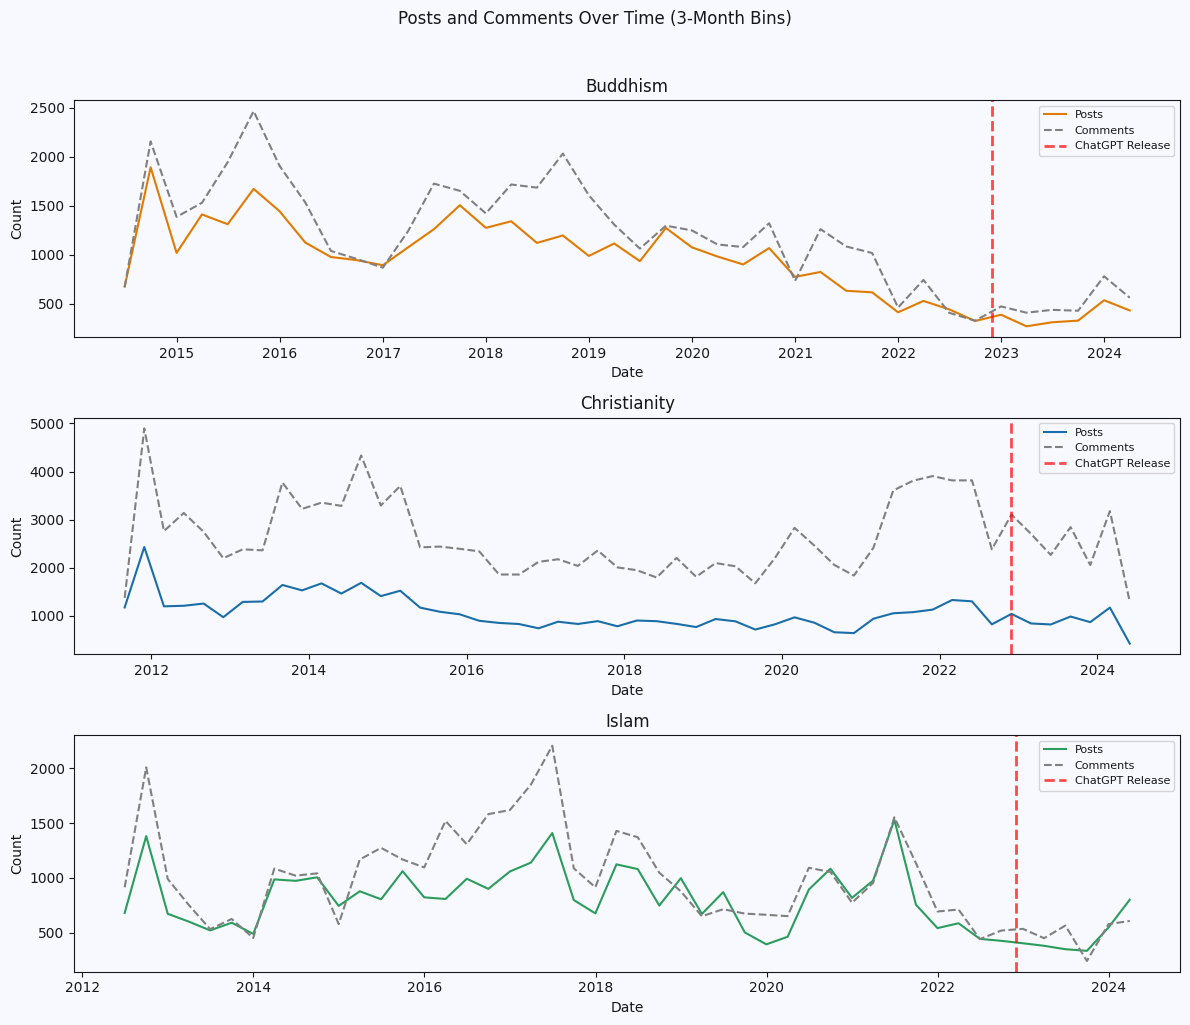

**Figure R1.** Posts and comments over time for each religion stack.

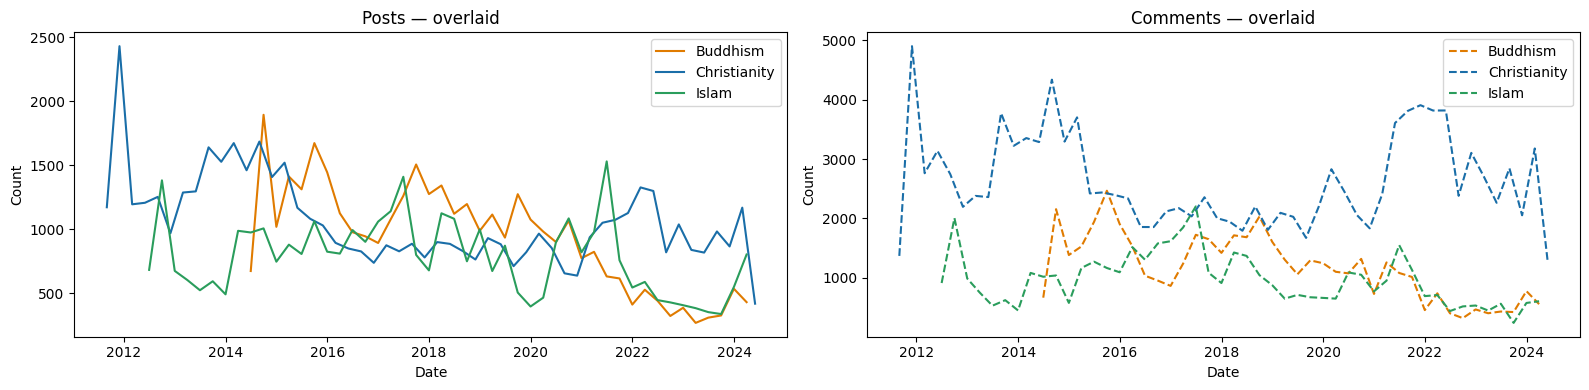

**Figure R2.** Overlaid post and comment volumes across all three stacks.

In [41]:
import seaborn as sns

BG_COLOR = '#f8f8ff'
TEXT_COLOR = '#16161D'

posts_3m_all    = {}
comments_3m_all = {}
for n in STACKS:
    p = stacks[n]['post_df']
    c = stacks[n]['comments_df']
    posts_3m_all[n]    = p.resample('3ME', on='CreationDate').count()['Id']
    comments_3m_all[n] = c.resample('3ME', on='CreationDate').count()['Id']

# Stacked vertically: one subplot per stack
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharey=False)
fig.patch.set_facecolor(BG_COLOR)
for ax, n in zip(axes, STACKS):
    ax.set_facecolor(BG_COLOR)
    ax.plot(posts_3m_all[n].index,    posts_3m_all[n].values,    label='Posts',    color=COLORS[n])
    ax.plot(comments_3m_all[n].index, comments_3m_all[n].values, label='Comments', color='grey', linestyle='--')
    ax.axvline(pd.Timestamp('2022-11-30'), color='red', linestyle='--', linewidth=2, label='ChatGPT Release', alpha=0.7)
    ax.set_title(LABELS[n], color=TEXT_COLOR)
    ax.set_xlabel('Date', color=TEXT_COLOR)
    ax.set_ylabel('Count', color=TEXT_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    ax.spines[:].set_color(TEXT_COLOR)
    ax.legend(fontsize=8, facecolor=BG_COLOR, labelcolor=TEXT_COLOR)
plt.suptitle('Posts and Comments Over Time (3-Month Bins)', y=1.02, color=TEXT_COLOR)
plt.tight_layout(); plt.show()
display(Markdown('**Figure R1.** Posts and comments over time for each religion stack.'))

# Overlaid
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for n in STACKS:
    axes[0].plot(posts_3m_all[n].index,    posts_3m_all[n].values,    label=LABELS[n], color=COLORS[n])
    axes[1].plot(comments_3m_all[n].index, comments_3m_all[n].values, label=LABELS[n], color=COLORS[n], linestyle='--')
axes[0].set_title('Posts — overlaid'); axes[0].set_xlabel('Date'); axes[0].set_ylabel('Count'); axes[0].legend()
axes[1].set_title('Comments — overlaid'); axes[1].set_xlabel('Date'); axes[1].set_ylabel('Count'); axes[1].legend()
plt.tight_layout(); plt.show()
display(Markdown('**Figure R2.** Overlaid post and comment volumes across all three stacks.'))


## Post Score Over Time

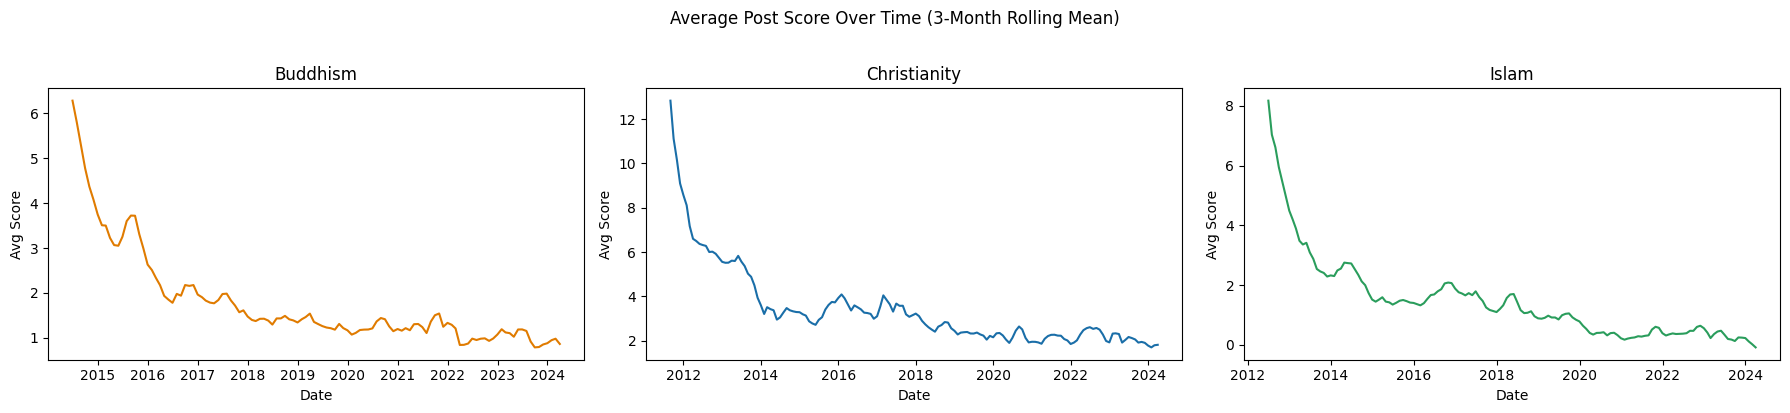

**Figure R3.** Average post score over time for each religion stack.

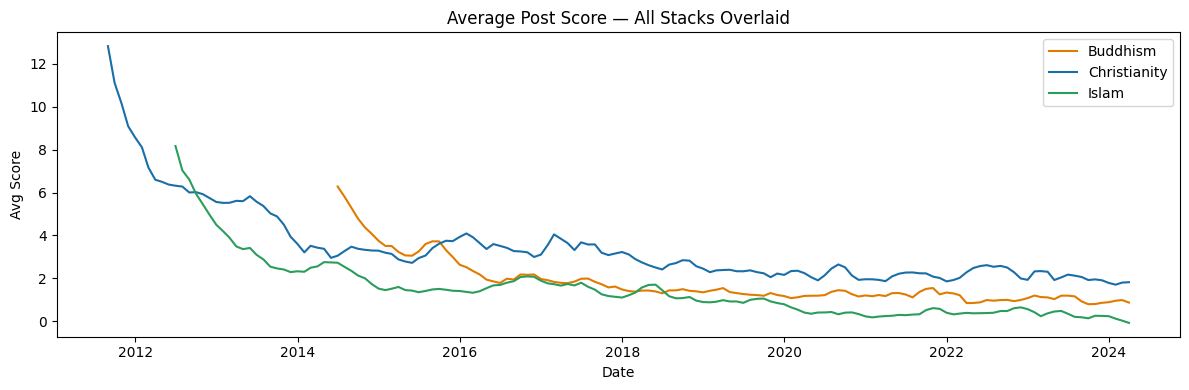

**Figure R4.** Overlaid average post score comparison.

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, n in zip(axes, STACKS):
    p = stacks[n]['post_df']
    monthly = p.resample('ME', on='CreationDate')['Score'].mean()
    rolling = monthly.rolling(window=3, min_periods=1).mean()
    ax.plot(rolling.index, rolling.values, color=COLORS[n])
    ax.set_title(LABELS[n]); ax.set_xlabel('Date'); ax.set_ylabel('Avg Score')
plt.suptitle('Average Post Score Over Time (3-Month Rolling Mean)', y=1.02)
plt.tight_layout(); plt.show()
display(Markdown('**Figure R3.** Average post score over time for each religion stack.'))

plt.figure(figsize=(12, 4))
for n in STACKS:
    p = stacks[n]['post_df']
    monthly = p.resample('ME', on='CreationDate')['Score'].mean()
    rolling = monthly.rolling(window=3, min_periods=1).mean()
    plt.plot(rolling.index, rolling.values, label=LABELS[n], color=COLORS[n])
plt.title('Average Post Score — All Stacks Overlaid')
plt.xlabel('Date'); plt.ylabel('Avg Score'); plt.legend()
plt.tight_layout(); plt.show()
display(Markdown('**Figure R4.** Overlaid average post score comparison.'))


## Lexical Features Over Time

Word count, average word length, URL count, and question-mark count per post (3-month bins).

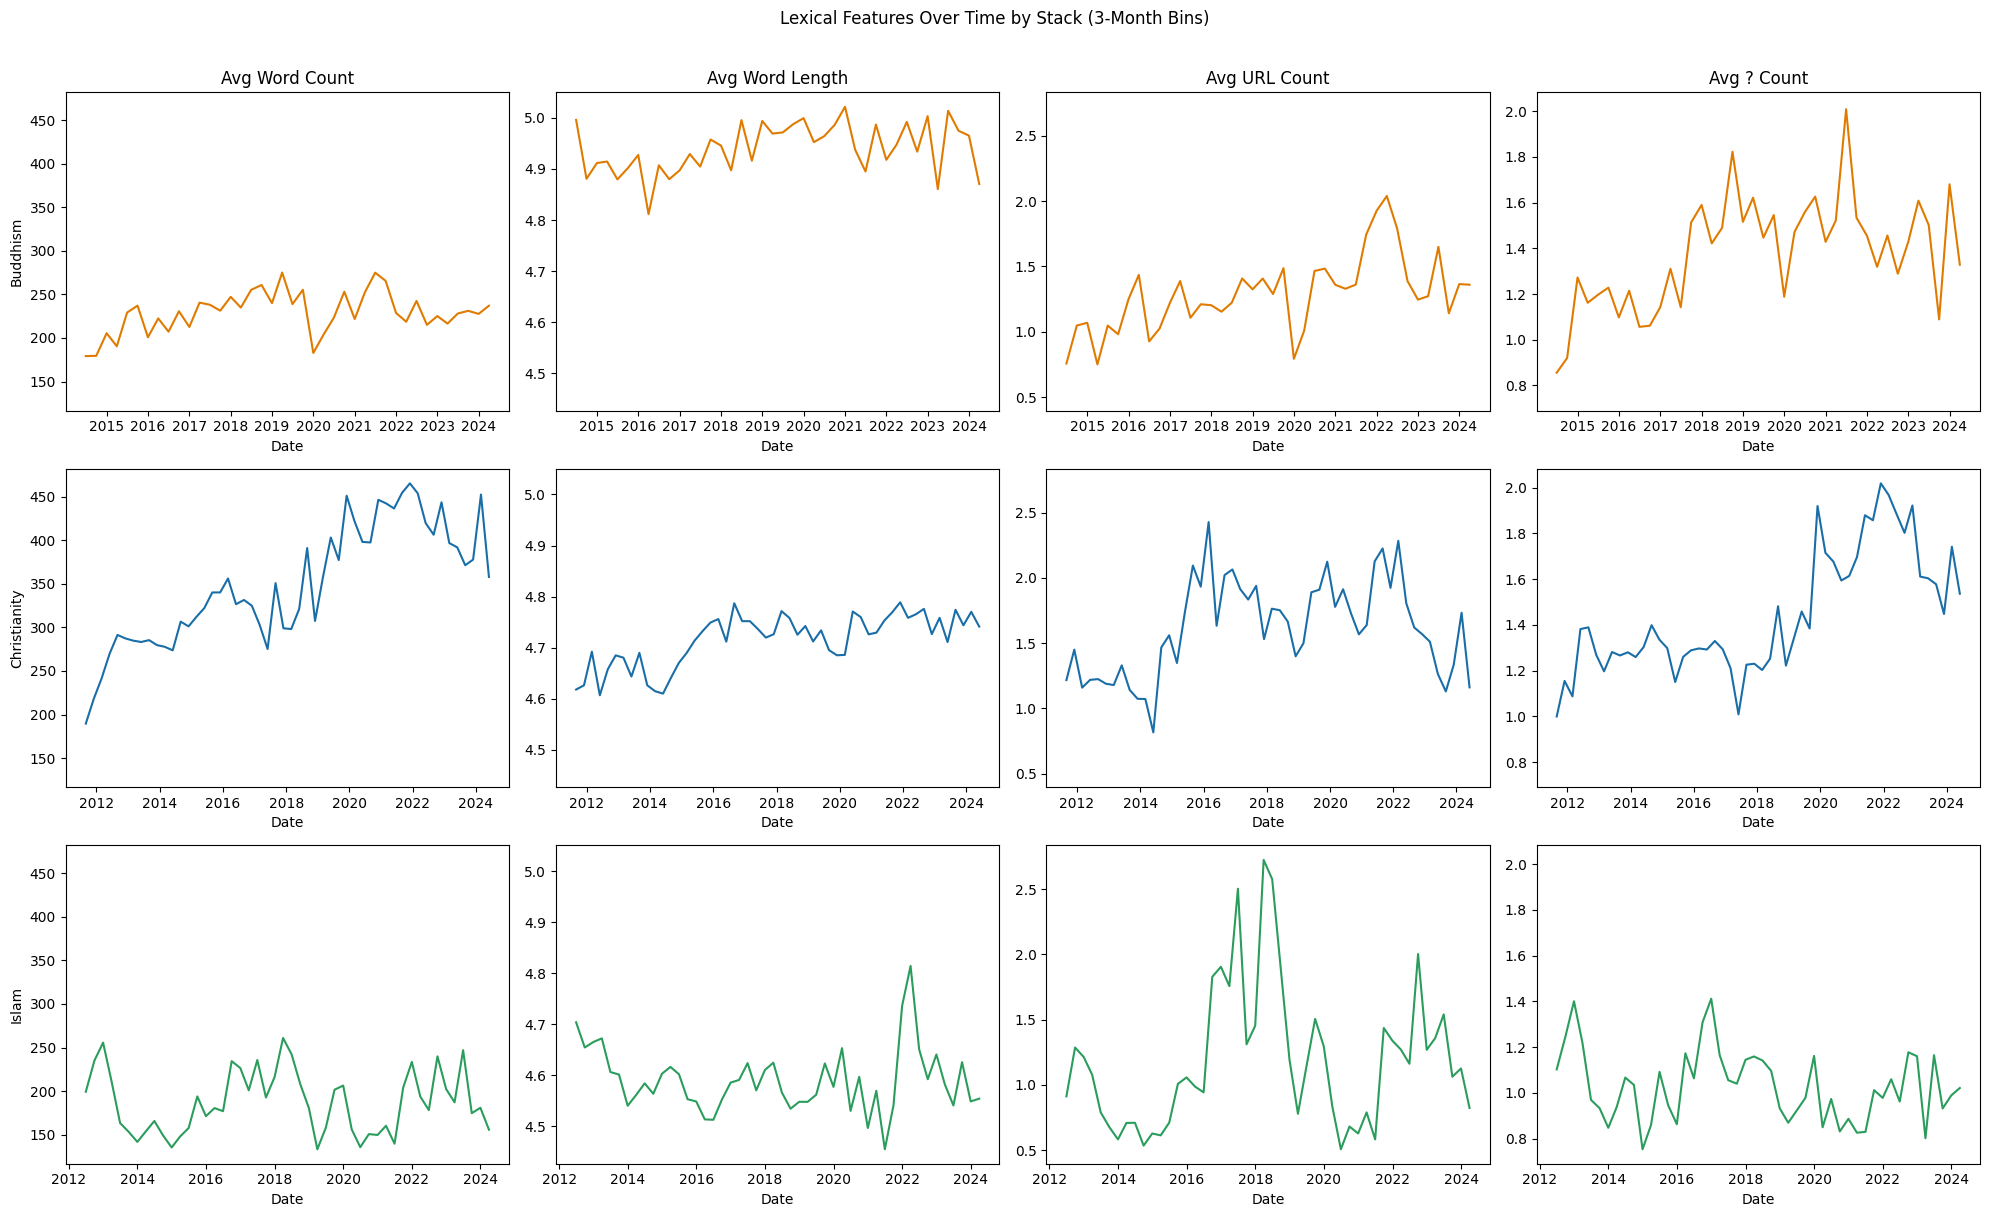

**Figure R5.** Lexical features over time. Rows = stacks, columns = features.

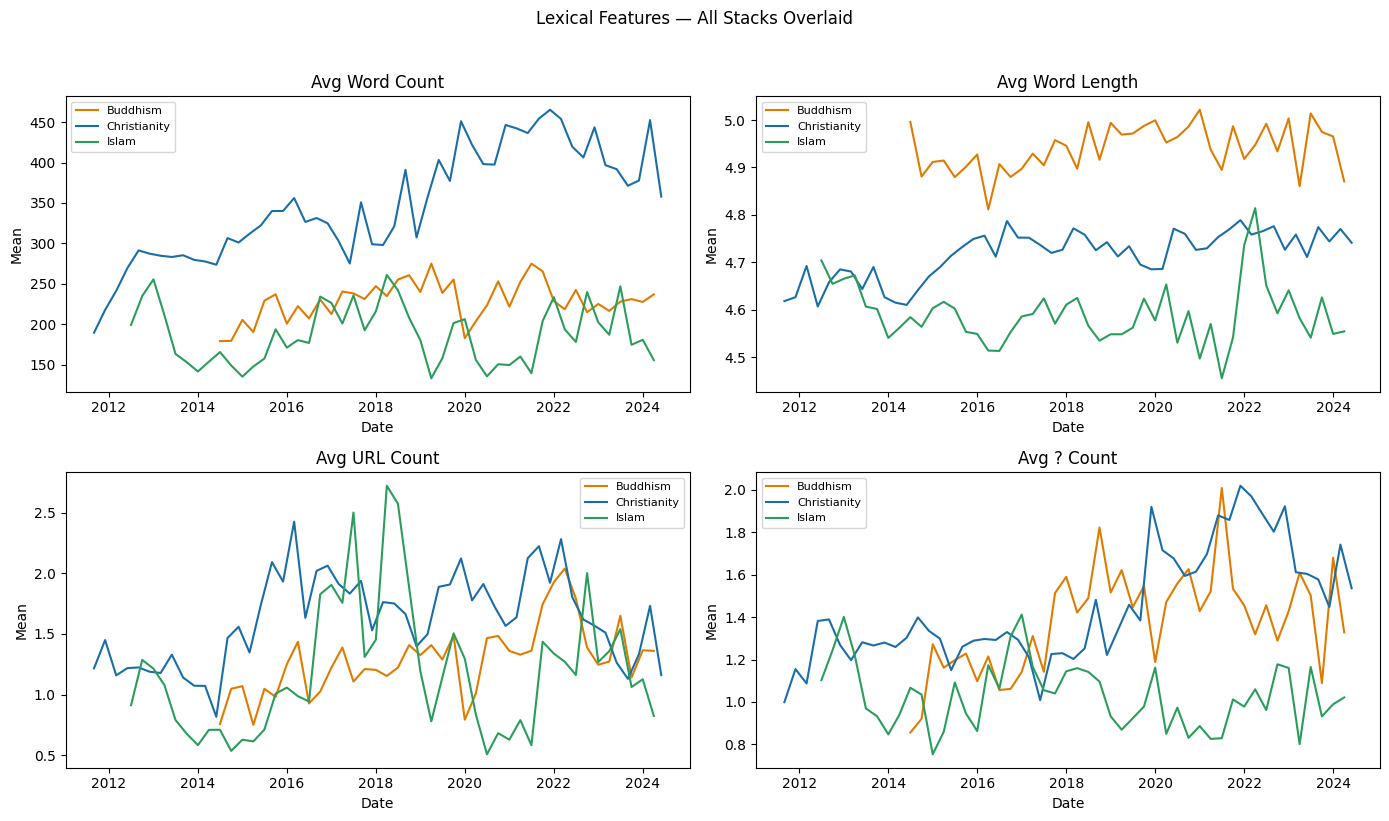

**Figure R6.** Overlaid lexical feature comparison.

**Word count vs URL count (r, 3-month bins):**

| Stack | r |
|-|-|
| Buddhism | 0.496 |
| Christianity | 0.542 |
| Islam | 0.843 |


In [12]:
def avg_word_length(text):
    try:
        words = text.split()
        return np.mean([len(w) for w in words]) if words else 0
    except:
        return 0

features_all = {}
for n in STACKS:
    p = stacks[n]['post_df'].copy()
    p['word_count']         = p['BodyText'].str.split().apply(len)
    p['avg_word_length']    = p['BodyText'].apply(avg_word_length)
    p['URL_count']          = p['BodyURLs'].apply(lambda u: len(u) if isinstance(u, list) else 0)
    p['question_mark_count']= p['BodyText'].str.count('\\?')
    features_all[n] = p.resample('3ME', on='CreationDate').agg(
        {'word_count': 'mean', 'avg_word_length': 'mean',
         'URL_count': 'mean',  'question_mark_count': 'mean'})

feat_names  = ['word_count', 'avg_word_length', 'URL_count', 'question_mark_count']
feat_labels = ['Avg Word Count', 'Avg Word Length', 'Avg URL Count', 'Avg ? Count']

# 3 rows x 4 cols grid
fig, axs = plt.subplots(3, 4, figsize=(20, 12), sharey='col')
for ri, n in enumerate(STACKS):
    for ci, (feat, flabel) in enumerate(zip(feat_names, feat_labels)):
        axs[ri, ci].plot(features_all[n].index, features_all[n][feat], color=COLORS[n])
        if ri == 0: axs[ri, ci].set_title(flabel)
        if ci == 0: axs[ri, ci].set_ylabel(LABELS[n])
        axs[ri, ci].set_xlabel('Date')
plt.suptitle('Lexical Features Over Time by Stack (3-Month Bins)', y=1.01)
plt.tight_layout(); plt.show()
display(Markdown('**Figure R5.** Lexical features over time. Rows = stacks, columns = features.'))

# Overlaid per feature
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat, flabel in zip(axs.flat, feat_names, feat_labels):
    for n in STACKS:
        ax.plot(features_all[n].index, features_all[n][feat], label=LABELS[n], color=COLORS[n])
    ax.set_title(flabel); ax.set_xlabel('Date'); ax.set_ylabel('Mean'); ax.legend(fontsize=8)
plt.suptitle('Lexical Features — All Stacks Overlaid', y=1.02)
plt.tight_layout(); plt.show()
display(Markdown('**Figure R6.** Overlaid lexical feature comparison.'))

md_corr = '**Word count vs URL count (r, 3-month bins):**\n\n| Stack | r |\n|-|-|\n'
for n in STACKS:
    r = features_all[n]['word_count'].corr(features_all[n]['URL_count'])
    md_corr += f'| {LABELS[n]} | {r:.3f} |\n'
display(Markdown(md_corr))


In [22]:
# is there a statisfically significant difference in word length between the three stacks? 
from scipy import stats
import scikit_posthocs as sp   # pip install scikit-posthocs

# --- 1. Extract raw per-post avg_word_length for each stack ---
awl = {}
for n in STACKS:
    p = stacks[n]['post_df'].copy()
    p['avg_word_length'] = p['BodyText'].apply(avg_word_length)
    awl[n] = p['avg_word_length'].dropna()
    awl[n] = awl[n][awl[n] > 0]   # drop empty posts

# --- 2. Descriptive summary ---
print("Descriptive statistics — avg word length per post\n")
for n in STACKS:
    s = awl[n]
    print(f"{LABELS[n]:15s}  n={len(s):6d}  median={s.median():.3f}  "
          f"mean={s.mean():.3f}  std={s.std():.3f}")

# --- 3. Kruskal-Wallis test (any difference across 3 stacks?) ---
stat, p_kw = stats.kruskal(*[awl[n] for n in STACKS])
print(f"\nKruskal-Wallis H = {stat:.3f},  p = {p_kw:.4e}")
if p_kw < 0.05:
    print("→ Significant difference between at least one pair of stacks (p < 0.05)")
else:
    print("→ No significant difference detected")

# --- 4. Dunn post-hoc test (which pairs differ?) ---
combined = pd.DataFrame({
    'awl':   pd.concat([awl[n] for n in STACKS], ignore_index=True),
    'stack': pd.concat([pd.Series([LABELS[n]] * len(awl[n])) for n in STACKS], ignore_index=True)
})

dunn = sp.posthoc_dunn(combined, val_col='awl', group_col='stack', p_adjust='bonferroni')
print("\nDunn post-hoc test (Bonferroni-adjusted p-values):")
print(dunn.round(4))

# --- 5. Effect size: epsilon-squared (for Kruskal-Wallis) ---
n_total = sum(len(awl[n]) for n in STACKS)
epsilon_sq = (stat - len(STACKS) + 1) / (n_total - len(STACKS))
print(f"\nEffect size (ε²) = {epsilon_sq:.4f}  "
      f"({'small' if epsilon_sq < 0.04 else 'medium' if epsilon_sq < 0.16 else 'large'})")


Descriptive statistics — avg word length per post

Buddhism         n= 37257  median=4.862  mean=4.935  std=0.708
Christianity     n= 55238  median=4.668  mean=4.706  std=0.439
Islam            n= 37777  median=4.536  mean=4.584  std=0.597

Kruskal-Wallis H = 11640.113,  p = 0.0000e+00
→ Significant difference between at least one pair of stacks (p < 0.05)

Dunn post-hoc test (Bonferroni-adjusted p-values):
              Buddhism  Christianity  Islam
Buddhism           1.0           0.0    0.0
Christianity       0.0           1.0    0.0
Islam              0.0           0.0    1.0

Effect size (ε²) = 0.0893  (medium)


Questions: Kruskal-Wallis H=3640.74, p=0.0000e+00
              Buddhism  Christianity  Islam
Buddhism           1.0           0.0    0.0
Christianity       0.0           1.0    0.0
Islam              0.0           0.0    1.0 

Answers: Kruskal-Wallis H=8395.23, p=0.0000e+00
              Buddhism  Christianity  Islam
Buddhism           1.0           0.0    0.0
Christianity       0.0           1.0    0.0
Islam              0.0           0.0    1.0 



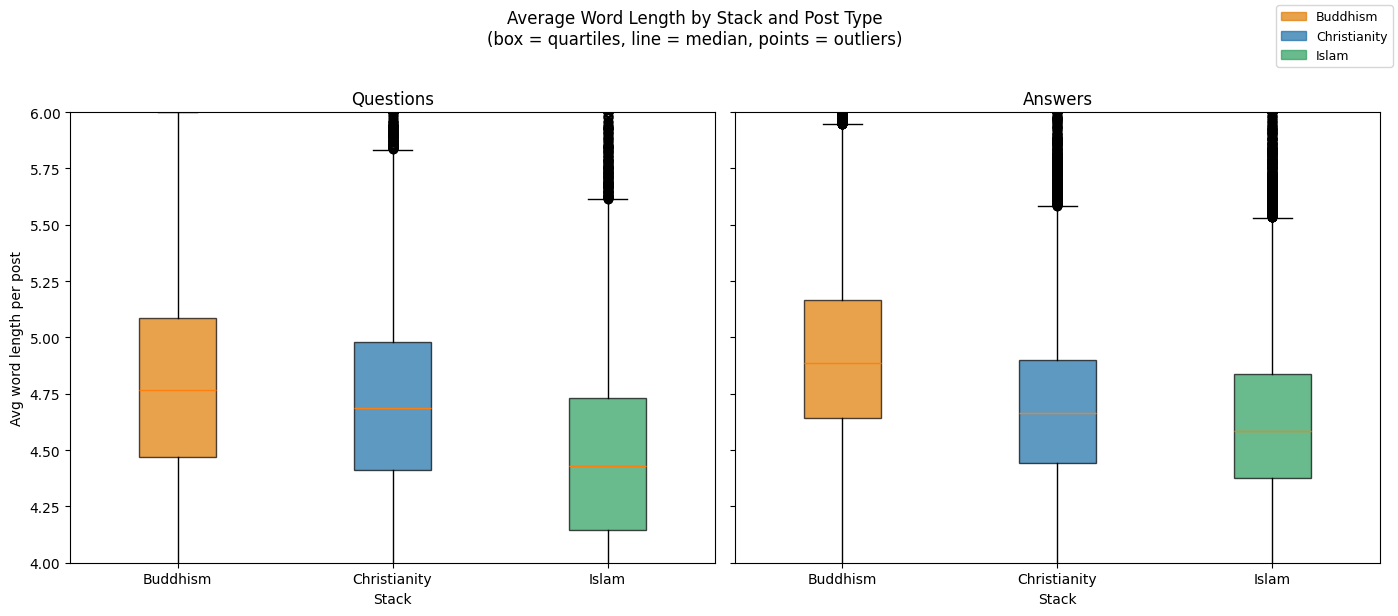

In [ ]:
# Compare average word length separately for questions and answers. 

# --- Prepare data ---
awl_by_type = {}
for n in STACKS:
    p = stacks[n]['post_df'].copy()
    p['avg_word_length'] = p['BodyText'].apply(avg_word_length)
    p = p[p['avg_word_length'] > 0]
    awl_by_type[n] = {
        'Questions': p[p['PostTypeId'] == '1']['avg_word_length'].values,
        'Answers':   p[p['PostTypeId'] == '2']['avg_word_length'].values,
    }

# --- Pairwise Kruskal-Wallis + Dunn per post type ---
def sig_stars(p):
    if pd.isna(p):
        return 'ns'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

for post_type in ['Questions', 'Answers']:
    groups = [awl_by_type[n][post_type] for n in STACKS]
    nonempty_groups = [g for g in groups if len(g) > 0]
    if len(nonempty_groups) < 2:
        print(f"{post_type}: Not enough non-empty groups for Kruskal-Wallis.")
        continue

    stat, p_kw = stats.kruskal(*nonempty_groups)
    print(f"{post_type}: Kruskal-Wallis H={stat:.2f}, p={p_kw:.4e}")

    combined = pd.DataFrame({
        'awl':   np.concatenate([g for g in groups if len(g) > 0]),
        'stack': np.repeat([LABELS[n] for n, g in zip(STACKS, groups) if len(g) > 0],
                           [len(g) for g in groups if len(g) > 0])
    })
    dunn = sp.posthoc_dunn(combined, val_col='awl', group_col='stack', p_adjust='bonferroni')
    print(dunn.round(4), "\n")

# --- Plot ---
post_types = ['Questions', 'Answers']
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

stack_names = list(LABELS.values())
x = np.arange(len(STACKS))
width = 0.6

for ax, post_type in zip(axes, post_types):
    groups = [awl_by_type[n][post_type] for n in STACKS]
    
    # Box plot
    box_data = [g for g in groups if len(g) > 0]
    box_positions = [i for i, g in enumerate(groups) if len(g) > 0]
    bp = ax.boxplot(box_data, positions=box_positions, widths=width * 0.6,
                    patch_artist=True, showfliers=True)
    
    # Color the boxes
    for patch, pos in zip(bp['boxes'], box_positions):
        patch.set_facecolor(COLORS[STACKS[pos]])
        patch.set_alpha(0.7)
    
    # axis formatting
    ax.set_ylim(4, 6)
    ax.set_xticks(x)
    ax.set_xticklabels(stack_names)
    ax.set_title(post_type)
    ax.set_ylabel('Avg word length per post' if post_type == 'Questions' else '')
    ax.set_xlabel('Stack')

# shared legend
handles = [plt.Rectangle((0,0),1,1, color=COLORS[n], alpha=0.7) for n in STACKS]
fig.legend(handles, stack_names, loc='upper right', fontsize=9)
plt.suptitle('Average Word Length by Stack and Post Type\n(box = quartiles, line = median, points = outliers)',
             y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# why's there so many outliers? code below checks the top 5 longest avg word length posts in each stack
# because there's link in them. 
for n in STACKS:
    p = stacks[n]['post_df'].copy()
    p['avg_word_length'] = p['BodyText'].apply(avg_word_length)
    p = p[p['avg_word_length'] > 0]
    
    # Get top 5 longest
    top_5 = p.nlargest(5, 'avg_word_length')[['Id', 'PostTypeId', 'avg_word_length', 'BodyText']]
    
    print(f"\n{LABELS[n]} - Top 5 Longest Avg Word Length:")
    print(f"{'Post ID':<10} {'Type':<8} {'Avg Length':<12} {'Preview':<50}")
    print("-" * 80)
    for idx, row in top_5.iterrows():
        post_type = 'Question' if row['PostTypeId'] == '1' else 'Answer'
        preview = row['BodyText'][:45] + '...' if len(row['BodyText']) > 45 else row['BodyText']
        print(f"{row['Id']:<10} {post_type:<8} {row['avg_word_length']:<12.3f} {preview:<50}")



Buddhism - Top 5 Longest Avg Word Length:
Post ID    Type     Avg Length   Preview                                           
--------------------------------------------------------------------------------
12770      Answer   51.778       Here are some links...... 
 http://mahamevnaw...  
22704      Answer   33.167       Possible source : The Buddha's Path To Delive...  
36102      Answer   32.556       Thanissaro Bhikkhu equates  papanca  with obj...  
41042      Answer   29.143       Additional site for sutta crossreferencing. 
...  
25554      Answer   27.375       read sutta on intergrity glhf
 https://www.ac...  

Christianity - Top 5 Longest Avg Word Length:
Post ID    Type     Avg Length   Preview                                           
--------------------------------------------------------------------------------
99403      Answer   17.625       Is this what you are looking for?  https://ar...  
94084      Answer   16.743       A paper that has an English translation: 
 

Buddhism:
  Correlation: 0.2810
  P-value: 0.0000e+00
  N posts: 37257

Christianity:
  Correlation: 0.2372
  P-value: 0.0000e+00
  N posts: 55238

Islam:
  Correlation: 0.3066
  P-value: 0.0000e+00
  N posts: 37777



/var/folders/3k/8s1j3_gd2x75nxccw2lzfmnr0000gn/T/ipykernel_82168/1188212206.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/var/folders/3k/8s1j3_gd2x75nxccw2lzfmnr0000gn/T/ipykernel_82168/1188212206.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/var/folders/3k/8s1j3_gd2x75nxccw2lzfmnr0000gn/T/ipykernel_82168/1188212206.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


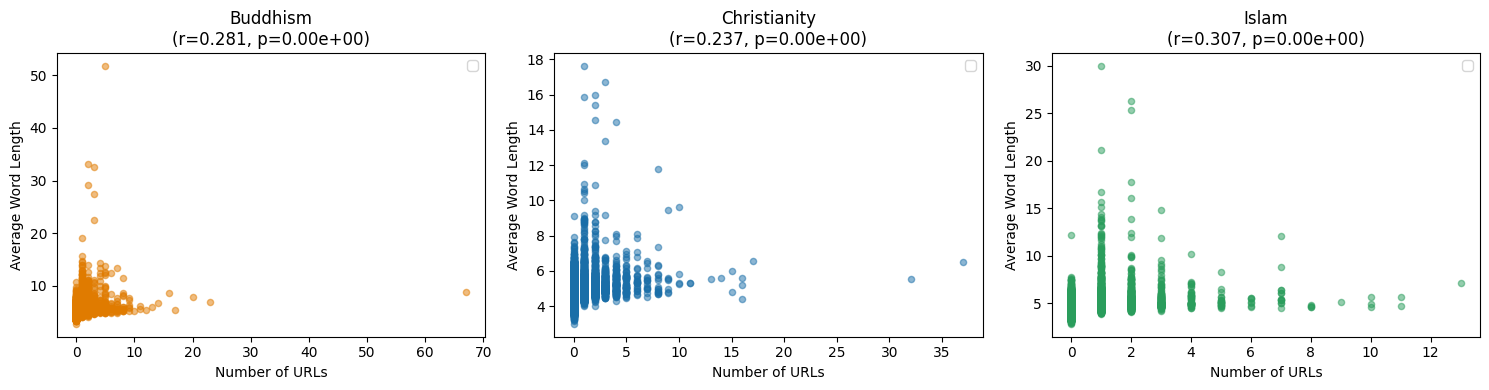

In [35]:
# --- Correlation: Number of URLs vs Average Word Length ---
import re

def count_urls(text):
    """Count the number of URLs in text"""
    if pd.isna(text):
        return 0
    url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    return len(re.findall(url_pattern, str(text)))

# Prepare data for correlation
correlation_results = {}

for n in STACKS:
    p = stacks[n]['post_df'].copy()
    p['avg_word_length'] = p['BodyText'].apply(avg_word_length)
    p['num_urls'] = p['BodyText'].apply(count_urls)
    
    # Filter to posts with valid data
    p = p[(p['avg_word_length'] > 0) & (p['num_urls'] >= 0)]
    
    # Calculate Pearson correlation
    corr_coef, p_val = stats.pearsonr(p['num_urls'], p['avg_word_length'])
    
    correlation_results[n] = {
        'correlation': corr_coef,
        'p_value': p_val,
        'n_posts': len(p)
    }
    
    print(f"{LABELS[n]}:")
    print(f"  Correlation: {corr_coef:.4f}")
    print(f"  P-value: {p_val:.4e}")
    print(f"  N posts: {len(p)}\n")

# --- Visualize correlation ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n in zip(axes, STACKS):
    p = stacks[n]['post_df'].copy()
    p['avg_word_length'] = p['BodyText'].apply(avg_word_length)
    p['num_urls'] = p['BodyText'].apply(count_urls)
    p = p[(p['avg_word_length'] > 0) & (p['num_urls'] >= 0)]
    
    # Scatter plot
    ax.scatter(p['num_urls'], p['avg_word_length'], alpha=0.5, s=20, color=COLORS[n])

    ax.set_xlabel('Number of URLs')
    ax.set_ylabel('Average Word Length')
    ax.set_title(f"{LABELS[n]}\n(r={correlation_results[n]['correlation']:.3f}, p={correlation_results[n]['p_value']:.2e})")
    ax.legend()

plt.tight_layout()
plt.show()


## Tag Analysis

**Table R5: Buddhism** — Top 10 tags

| Tag | Total | First used | Most active |
|-|-|-|-|
| theravada | 802 | 2014-06-17 | 2015-09 |
| personal-practice | 738 | 2014-06-18 | 2015-07 |
| reference-request | 558 | 2014-06-17 | 2015-12 |
| meditation | 544 | 2015-03-24 | 2017-10 |
| pali-canon | 512 | 2014-06-22 | 2018-12 |
| karma | 500 | 2014-06-17 | 2014-06 |
| philosophy | 400 | 2014-06-17 | 2014-06 |
| the-buddha | 395 | 2014-06-17 | 2015-06 |
| sutras | 368 | 2014-06-18 | 2015-11 |
| vipassana | 368 | 2014-06-21 | 2014-09 |


**Table R5: Christianity** — Top 10 tags

| Tag | Total | First used | Most active |
|-|-|-|-|
| catholicism | 4025 | 2011-08-23 | 2017-03 |
| exegesis | 1487 | 2011-08-23 | 2011-09 |
| biblical-basis | 1107 | 2011-08-23 | 2011-08 |
| life-of-jesus | 963 | 2011-08-23 | 2013-03 |
| church-history | 842 | 2011-08-23 | 2011-09 |
| bible | 663 | 2011-08-23 | 2011-09 |
| nature-of-god | 651 | 2011-08-23 | 2011-09 |
| protestantism | 632 | 2011-08-23 | 2022-05 |
| soteriology | 605 | 2011-08-23 | 2011-09 |
| lds | 597 | 2011-08-24 | 2013-12 |


**Table R5: Islam** — Top 10 tags

| Tag | Total | First used | Most active |
|-|-|-|-|
| halal-haram | 2268 | 2012-06-19 | 2021-04 |
| quran | 1657 | 2012-06-19 | 2018-04 |
| hadith | 1557 | 2012-06-19 | 2020-09 |
| salat | 1353 | 2012-06-19 | 2014-01 |
| fiqh | 968 | 2012-06-19 | 2012-07 |
| practical-islam | 867 | 2012-06-20 | 2021-04 |
| nikah | 844 | 2012-06-19 | 2017-05 |
| sharia | 711 | 2012-06-20 | 2014-07 |
| tafseer | 691 | 2012-06-19 | 2018-04 |
| hadith-interpretation | 587 | 2012-07-21 | 2021-08 |


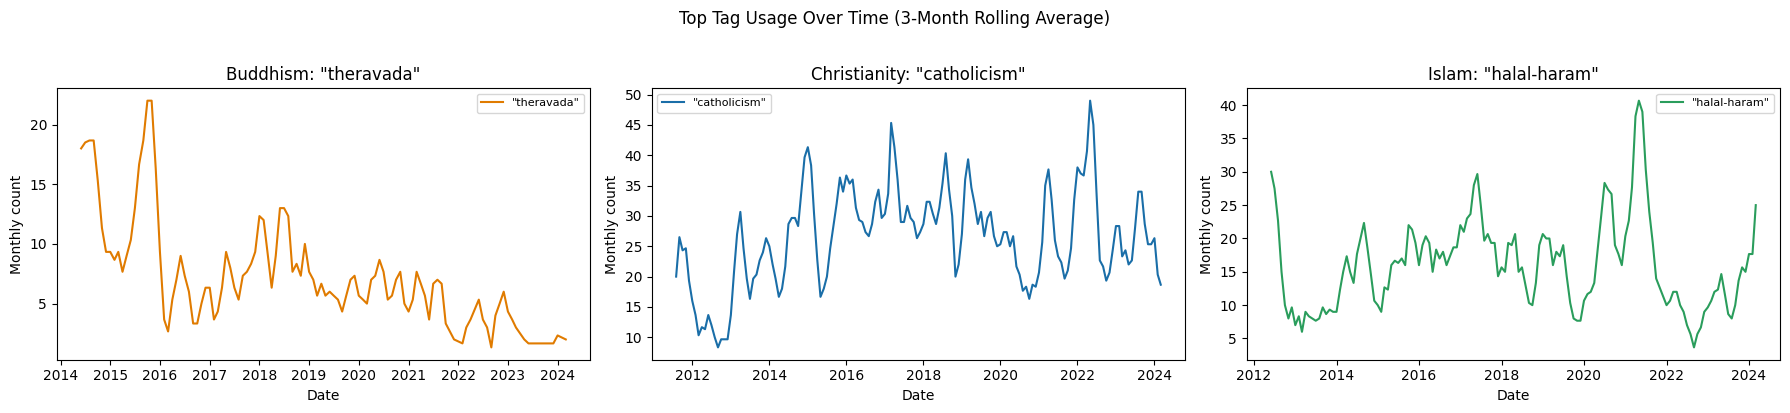

**Figure R7.** Top tag usage over time for each religion stack.


**Table R5 (comparison).** Top 10 tags by stack.

| Rank | Buddhism | Christianity | Islam |
|-|-|-|-|
| 1 | theravada (802) | catholicism (4025) | halal-haram (2268) |
| 2 | personal-practice (738) | exegesis (1487) | quran (1657) |
| 3 | reference-request (558) | biblical-basis (1107) | hadith (1557) |
| 4 | meditation (544) | life-of-jesus (963) | salat (1353) |
| 5 | pali-canon (512) | church-history (842) | fiqh (968) |
| 6 | karma (500) | bible (663) | practical-islam (867) |
| 7 | philosophy (400) | nature-of-god (651) | nikah (844) |
| 8 | the-buddha (395) | protestantism (632) | sharia (711) |
| 9 | sutras (368) | soteriology (605) | tafseer (691) |
| 10 | vipassana (368) | lds (597) | hadith-interpretation (587) |

In [13]:
tag_data = {}
for n in STACKS:
    p = stacks[n]['post_df']
    qdf = p[p['PostTypeId'] == '1'].copy()
    qdf['TagsParsed'] = qdf['Tags'].apply(
        lambda t: [x for x in str(t).strip('|').split('|') if x] if pd.notna(t) else [])
    te = qdf[['Id', 'CreationDate', 'TagsParsed']].explode('TagsParsed')
    te = te.rename(columns={'TagsParsed': 'Tag'}).reset_index(drop=True)
    te = te[te['Tag'].notna() & (te['Tag'] != '')]
    top_tags = te['Tag'].value_counts().head(10).index.tolist()
    rows_t = []
    for tag in top_tags:
        tdf = te[te['Tag'] == tag].copy()
        tdf['Month'] = tdf['CreationDate'].dt.to_period('M')
        rows_t.append((tag, len(tdf), tdf['CreationDate'].min().strftime('%Y-%m-%d'),
                       tdf['Month'].value_counts().idxmax().strftime('%Y-%m')))
    tag_data[n] = {'rows': rows_t, 'tags_ex': te}

for n in STACKS:
    md_table = f'**Table R5: {LABELS[n]}** — Top 10 tags\n\n| Tag | Total | First used | Most active |\n|-|-|-|-|\n'
    for tag, total, fd, ma in tag_data[n]['rows']:
        md_table += f'| {tag} | {total} | {fd} | {ma} |\n'
    display(Markdown(md_table))

# Top-tag trend per stack
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, n in zip(axes, STACKS):
    top_tag = tag_data[n]['rows'][0][0]
    te = tag_data[n]['tags_ex']
    tm = te[te['Tag'] == top_tag].groupby(te['CreationDate'].dt.to_period('M')).size()
    tm.index = tm.index.to_timestamp()
    tr = tm.rolling(window=3, min_periods=1).mean()
    ax.plot(tr.index, tr.values, color=COLORS[n], label=f'"{top_tag}"')
    ax.set_title(f'{LABELS[n]}: "{top_tag}"'); ax.set_xlabel('Date'); ax.set_ylabel('Monthly count'); ax.legend(fontsize=8)
plt.suptitle('Top Tag Usage Over Time (3-Month Rolling Average)', y=1.02)
plt.tight_layout(); plt.show()
display(Markdown('**Figure R7.** Top tag usage over time for each religion stack.'))

# Rank comparison table
hdr = '| Rank | ' + ' | '.join(LABELS[n] for n in STACKS) + ' |'
sep = '|-' + '|-' * len(STACKS) + '|'
table = hdr + '\n' + sep
for rank in range(10):
    vals = []
    for n in STACKS:
        r = tag_data[n]['rows']
        vals.append(f"{r[rank][0]} ({r[rank][1]})" if rank < len(r) else '—')
    table += '\n| ' + str(rank+1) + ' | ' + ' | '.join(vals) + ' |'
display(Markdown('\n**Table R5 (comparison).** Top 10 tags by stack.\n\n' + table))


## Weeks of days


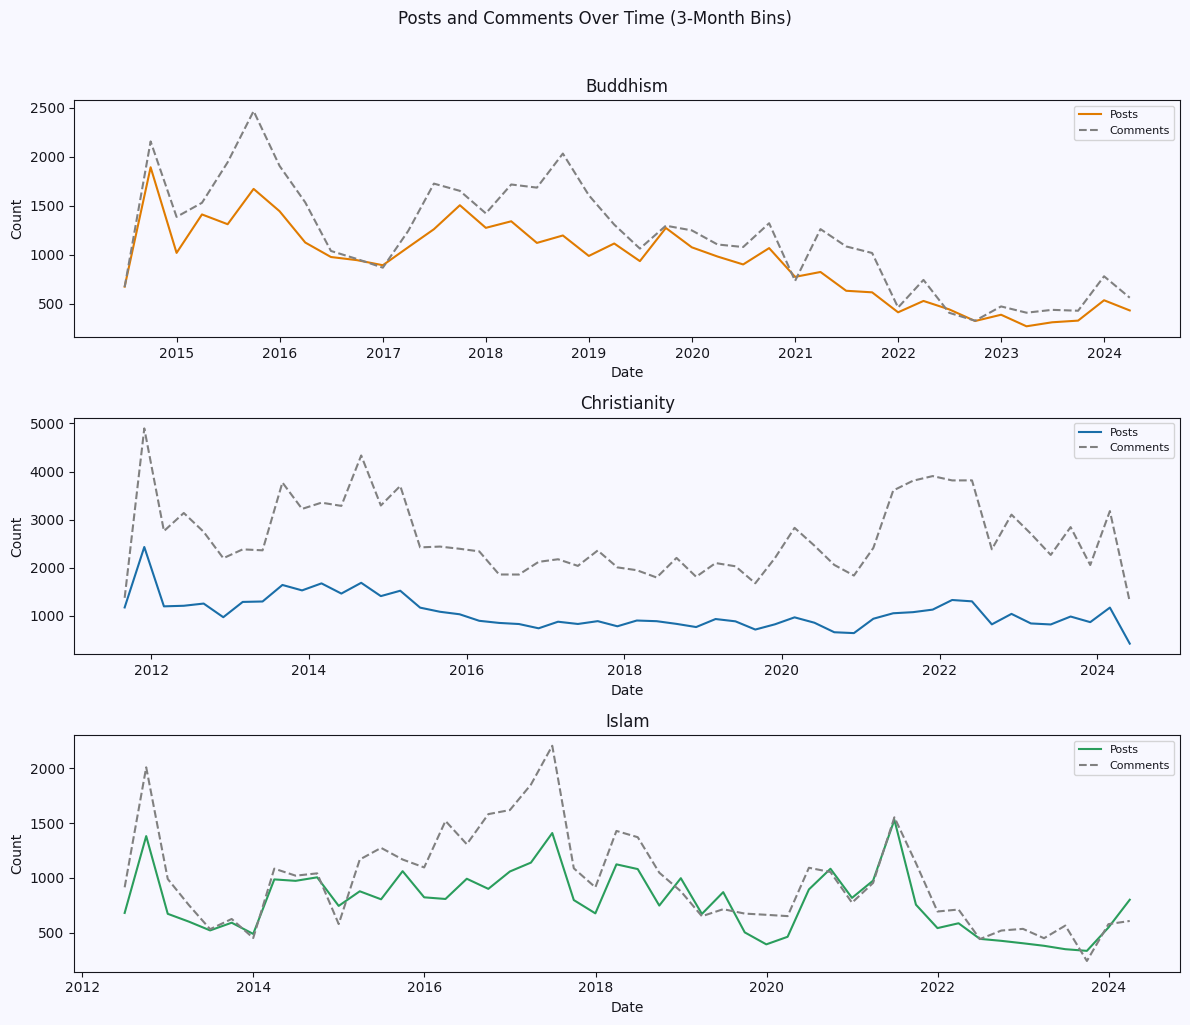

**Figure R1.** Posts and comments over time for each religion stack.

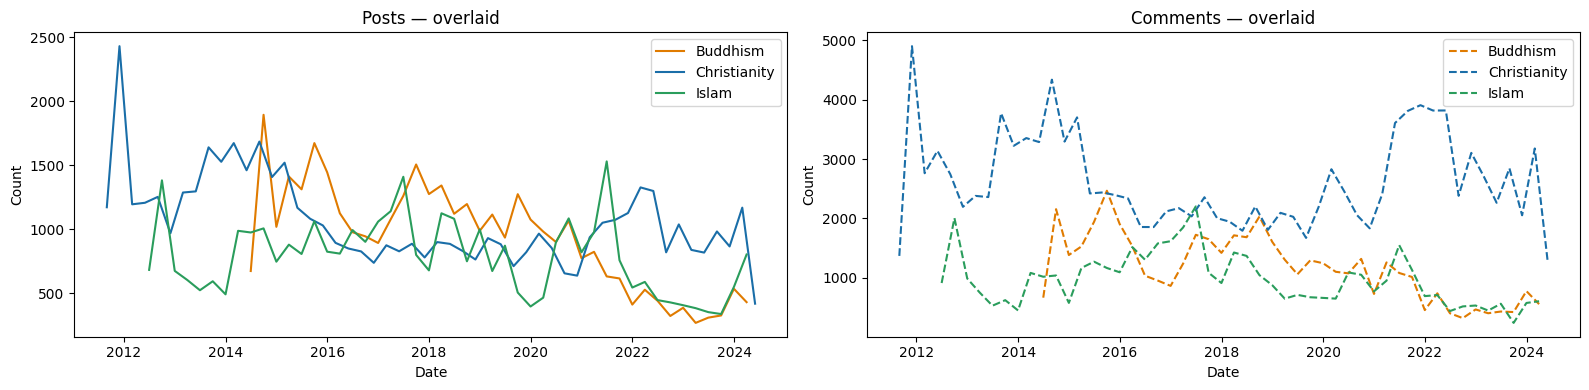

**Figure R2.** Overlaid post and comment volumes across all three stacks.

**Pearson correlation (posts vs comments, 3-month bins):**

| Stack | r | p |
|-|-|-|
| Buddhism | 0.928 | 7.37e-18 |
| Christianity | 0.807 | 5.07e-13 |
| Islam | 0.854 | 1.2e-14 |


In [ ]:
# to be udpated; accidently deleted the code 

## Social Structure of the Stack Exchanges

Each Stack Exchange is a social structure where questions form root nodes, and answers/comments form shallow branches. Below we summarise the thread structure and user networks across all three religion stacks.


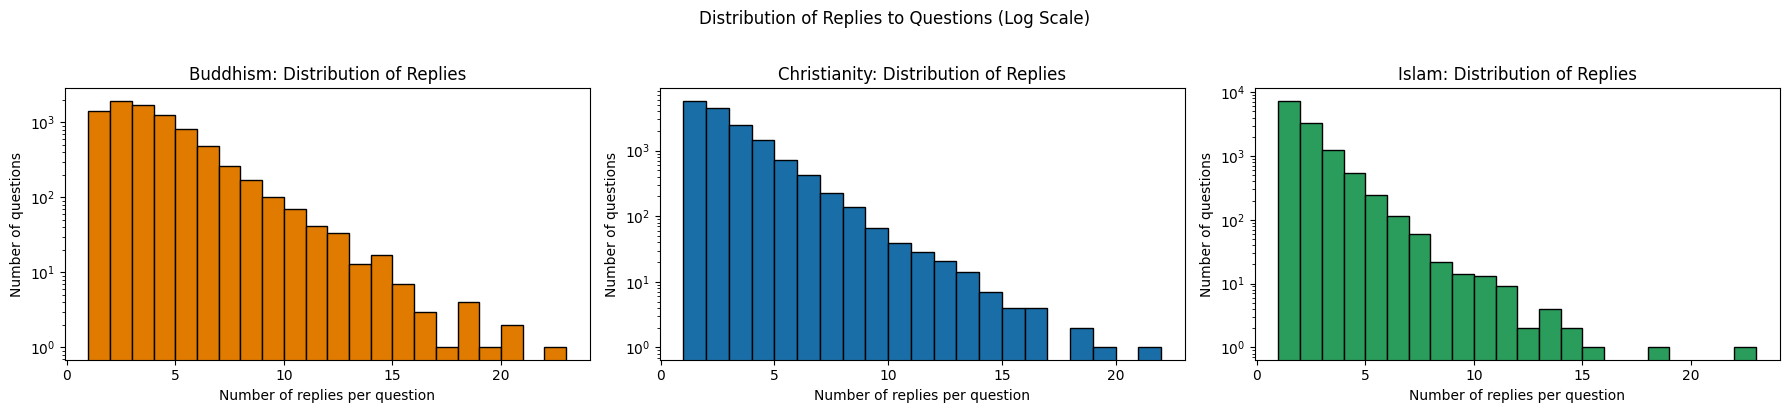

**Figure R9.** Distribution of replies to questions for each religion stack (log scale).

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, n in zip(axes, STACKS):
    p = stacks[n]['post_df']
    answer_df_n = p[p['PostTypeId'] == '2']
    counts = answer_df_n['ParentId'].value_counts()
    if len(counts) == 0:
        continue
    ax.hist(counts.values, bins=range(1, counts.max() + 2), edgecolor='black', color=COLORS[n])
    ax.set_title(f'{LABELS[n]}: Distribution of Replies')
    ax.set_xlabel('Number of replies per question')
    ax.set_ylabel('Number of questions')
    ax.set_yscale('log')
plt.suptitle('Distribution of Replies to Questions (Log Scale)', y=1.02)
plt.tight_layout()
plt.show()
display(Markdown('**Figure R9.** Distribution of replies to questions for each religion stack (log scale).'))


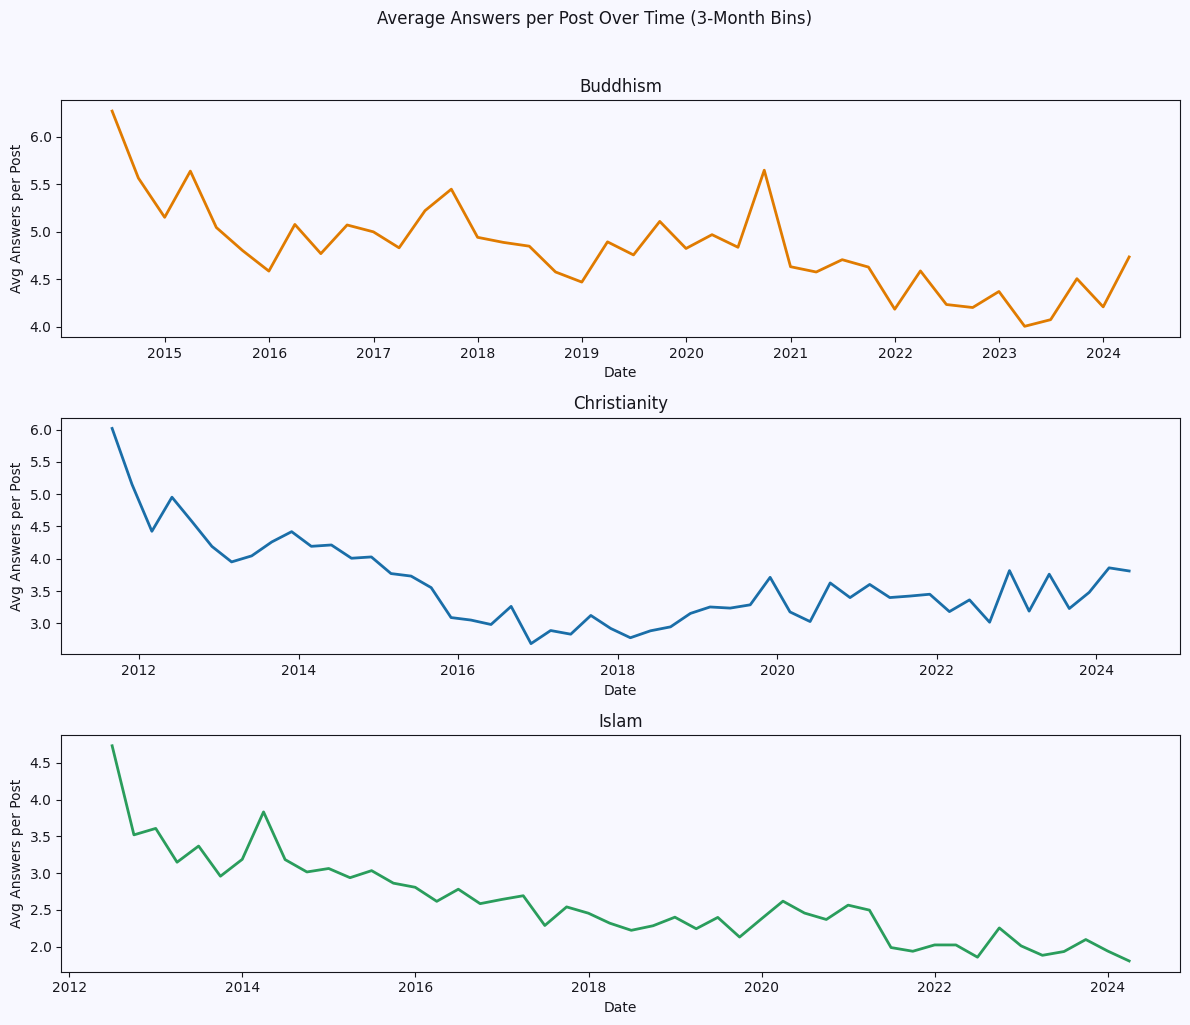

In [43]:
# --- Visualize number of answers per post over time ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharey=False)
fig.patch.set_facecolor(BG_COLOR)

for ax, n in zip(axes, STACKS):
    ax.set_facecolor(BG_COLOR)
    p = stacks[n]['post_df']
    answer_df_n = p[p['PostTypeId'] == '2']
    counts = answer_df_n['ParentId'].value_counts()
    
    # Merge counts back to answers and resample by creation date
    answer_df_n = answer_df_n.copy()
    answer_df_n['num_answers_to_post'] = answer_df_n['ParentId'].map(counts)
    
    answers_over_time = answer_df_n.groupby(pd.Grouper(key='CreationDate', freq='3ME'))['num_answers_to_post'].mean()
    
    ax.plot(answers_over_time.index, answers_over_time.values, color=COLORS[n], linewidth=2)
    ax.set_title(LABELS[n], color=TEXT_COLOR)
    ax.set_xlabel('Date', color=TEXT_COLOR)
    ax.set_ylabel('Avg Answers per Post', color=TEXT_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    ax.spines[:].set_color(TEXT_COLOR)

plt.suptitle('Average Answers per Post Over Time (3-Month Bins)', y=1.02, color=TEXT_COLOR)
plt.tight_layout()
plt.show()



### Author Network Structure

Here we model the reply network as a directed graph where an edge goes from the answerer to the question-asker. We report metrics for the full dataset and three time windows (first year, middle year, last year). Red nodes in the middle and last-year graphs indicate users who were present in the first year.


In [16]:
import networkx as nx
from collections import Counter

def get_reciprocity(g):
    return int(nx.reciprocity(g) * g.number_of_edges() / 2)

def get_lcc_size(g, wcc=True):
    if isinstance(g, nx.DiGraph):
        components = nx.weakly_connected_components(g) if wcc else nx.strongly_connected_components(g)
    else:
        components = nx.connected_components(g)
    return max((len(c) for c in components), default=0)

def make_weighted_digraph(df, source_col, target_col):
    edge_list = list(zip(df[source_col], df[target_col]))
    edge_counter = Counter(edge_list)
    g = nx.DiGraph()
    g.add_edges_from((u, v, {'weight': w}) for (u, v), w in edge_counter.items())
    return g

one_year   = pd.DateOffset(years=1)
six_months = pd.DateOffset(months=6)

network_data  = {}
time_window_dfs = {}

for n in STACKS:
    p  = stacks[n]['post_df']
    q_df = p[p['PostTypeId'] == '1']
    a_df = p[p['PostTypeId'] == '2']

    merged = a_df.merge(
        q_df[['Id', 'OwnerUserId']],
        left_on='ParentId', right_on='Id',
        how='left', suffixes=('_source', '_target')
    ).dropna(subset=['OwnerUserId_target'])

    first_year_end   = merged['CreationDate'].min() + one_year
    middle_post      = merged['CreationDate'].median()
    last_year_begin  = merged['CreationDate'].max() - one_year

    first_df  = merged[merged['CreationDate'] < first_year_end]
    middle_df = merged[(merged['CreationDate'] >= middle_post - six_months) &
                       (merged['CreationDate'] <= middle_post + six_months)]
    last_df   = merged[merged['CreationDate'] > last_year_begin]

    time_window_dfs[n] = {'all': merged, 'first': first_df, 'middle': middle_df, 'last': last_df}

    report_cols = []
    for window_df in [merged, first_df, middle_df, last_df]:
        g = make_weighted_digraph(window_df, 'OwnerUserId_source', 'OwnerUserId_target')
        in_degrees = dict(g.in_degree()).values()
        report_cols.append({
            'n_users':        len(g.nodes),
            'n_edges':        len(g.edges),
            'n_reciprocated': get_reciprocity(g),
            'size_lwcc':      get_lcc_size(g, wcc=True),
            'size_lscc':      get_lcc_size(g, wcc=False),
            'max_indegree':   max(in_degrees) if in_degrees else 0,
        })

    report_df = pd.DataFrame(report_cols,
                             index=['All time', 'First year', 'Middle year', 'Last year']).T
    network_data[n] = report_df
    display(Markdown(f'**Table R6: {LABELS[n]}** — Reply network metrics across time windows.'))
    display(report_df)


**Table R6: Buddhism** — Reply network metrics across time windows.

,All time,First year,Middle year,Last year
n_users,3904,665,706,287
n_edges,14935,2597,2149,811
n_reciprocated,372,100,48,27
size_lwcc,3890,663,664,270
size_lscc,411,105,57,19
max_indegree,269,126,66,22


**Table R6: Christianity** — Reply network metrics across time windows.

,All time,First year,Middle year,Last year
n_users,8321,679,1097,769
n_edges,25066,3101,1733,1909
n_reciprocated,659,170,12,38
size_lwcc,8208,679,910,719
size_lscc,789,159,53,64
max_indegree,419,105,41,88


**Table R6: Islam** — Reply network metrics across time windows.

,All time,First year,Middle year,Last year
n_users,9356,433,1431,709
n_edges,17298,1416,1853,806
n_reciprocated,183,67,19,2
size_lwcc,8802,424,1125,505
size_lscc,376,71,49,2
max_indegree,202,62,95,18


### Author Participation Over Time

The three network snapshots below show the reply graph in the first year, middle year, and last year for each religion stack. In the middle and last-year panels, red nodes are users who also appeared in the first year — a proxy for community retention.


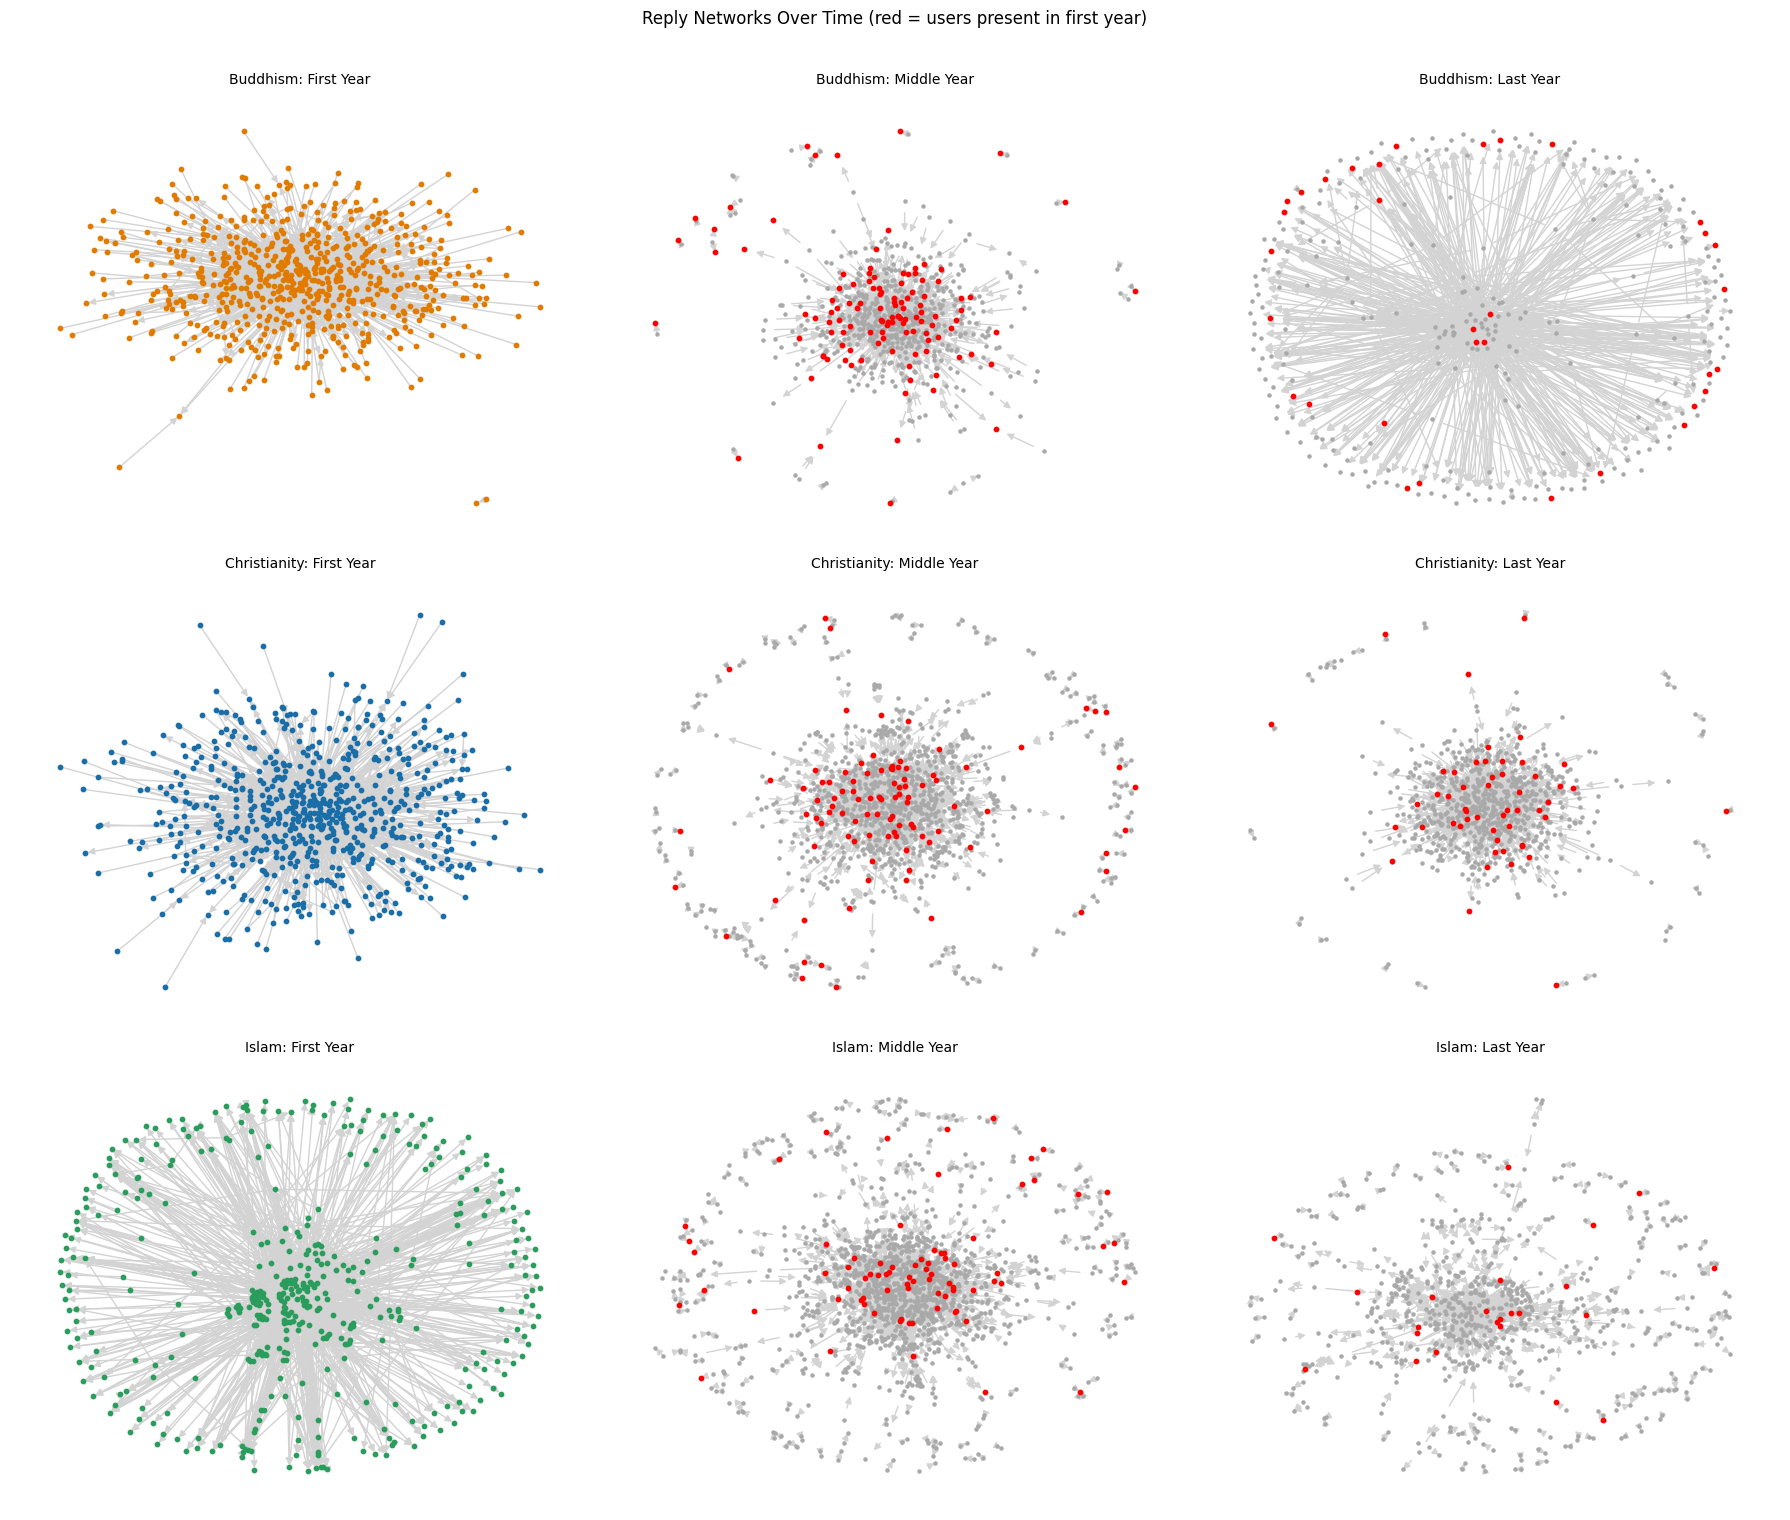

**Figure R10.** Reply networks across three time windows for each religion stack. Red nodes indicate users active in the first year.

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for ri, n in enumerate(STACKS):
    windows = time_window_dfs[n]
    ax_row = axes[ri]
    for ax in ax_row:
        ax.set_frame_on(False)

    # First year graph
    g_first = make_weighted_digraph(windows['first'], 'OwnerUserId_source', 'OwnerUserId_target')
    g_first.remove_edges_from(nx.selfloop_edges(g_first))
    pos_first = nx.spring_layout(g_first, seed=42)
    nx.draw(g_first, pos_first, ax=ax_row[0], node_color=COLORS[n], node_size=10, edge_color='lightgrey')
    ax_row[0].set_title(f'{LABELS[n]}: First Year', fontsize=10)
    first_nodes = set(g_first.nodes)

    # Middle year graph
    g_mid = make_weighted_digraph(windows['middle'], 'OwnerUserId_source', 'OwnerUserId_target')
    g_mid.remove_edges_from(nx.selfloop_edges(g_mid))
    pos_mid = nx.spring_layout(g_mid, seed=42)
    returning = first_nodes & set(g_mid.nodes)
    new_users = set(g_mid.nodes) - first_nodes
    nx.draw_networkx_edges(g_mid, pos_mid, ax=ax_row[1], edge_color='lightgrey')
    nx.draw_networkx_nodes(g_mid, pos_mid, ax=ax_row[1], nodelist=list(new_users), node_color='darkgrey', node_size=5)
    nx.draw_networkx_nodes(g_mid, pos_mid, ax=ax_row[1], nodelist=list(returning), node_color='red', node_size=10)
    ax_row[1].set_title(f'{LABELS[n]}: Middle Year', fontsize=10)

    # Last year graph
    g_last = make_weighted_digraph(windows['last'], 'OwnerUserId_source', 'OwnerUserId_target')
    g_last.remove_edges_from(nx.selfloop_edges(g_last))
    pos_last = nx.spring_layout(g_last, seed=42)
    returning = first_nodes & set(g_last.nodes)
    new_users = set(g_last.nodes) - first_nodes
    nx.draw_networkx_edges(g_last, pos_last, ax=ax_row[2], edge_color='lightgrey')
    nx.draw_networkx_nodes(g_last, pos_last, ax=ax_row[2], nodelist=list(new_users), node_color='darkgrey', node_size=5)
    nx.draw_networkx_nodes(g_last, pos_last, ax=ax_row[2], nodelist=list(returning), node_color='red', node_size=10)
    ax_row[2].set_title(f'{LABELS[n]}: Last Year', fontsize=10)

plt.suptitle('Reply Networks Over Time (red = users present in first year)', y=1.01)
plt.tight_layout()
plt.show()
display(Markdown('**Figure R10.** Reply networks across three time windows for each religion stack. Red nodes indicate users active in the first year.'))


## Text Analysis

In this section we investigate the textual content of posts using a bag-of-words approach. We apply TF-IDF to identify the most informative words per stack, then use a Naive Bayes classifier to find words that best distinguish questions from answers.


In [18]:
import nltk # pip install nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer # pip install scikit-learn
from nltk.stem import WordNetLemmatizer
from functools import partial

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

_stop_words = set(stopwords.words('english'))
_lemmatizer = WordNetLemmatizer()

def tokenize(text, lemma=False, stop=True):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha()]
    if stop:
        tokens = [t for t in tokens if t not in _stop_words]
    if lemma:
        tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return tokens

top_n = 20
configs = {
    'stop+no_lemma':    partial(tokenize, lemma=False, stop=True),
    'stop+lemma':       partial(tokenize, lemma=True,  stop=True),
    'no_stop+no_lemma': partial(tokenize, lemma=False, stop=False),
    'no_stop+lemma':    partial(tokenize, lemma=True,  stop=False),
}

for n in STACKS:
    p = stacks[n]['post_df']
    corpus = p['BodyText'].dropna().iloc[:1000]
    columns = {}
    for cfg_name, tok_fn in configs.items():
        vec = TfidfVectorizer(tokenizer=tok_fn)
        matrix = vec.fit_transform(corpus)
        features = vec.get_feature_names_out()
        means = np.asarray(matrix.mean(axis=0)).flatten()
        top_idx = means.argsort()[::-1][:top_n]
        columns[cfg_name] = [f"{features[i]} ({means[i]:.3f})" for i in top_idx]
    result = pd.DataFrame(columns, index=range(1, top_n + 1))
    result.index.name = 'rank'
    display(Markdown(f'**Table R7: {LABELS[n]}** — Top {top_n} TF-IDF terms under four tokenisation configurations (first 1,000 posts).'))
    display(result)


/Users/jiayanlin/Documents/Computational Methods/compmeth26/.venv/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


**Table R7: Buddhism** — Top 20 TF-IDF terms under four tokenisation configurations (first 1,000 posts).

,stop+no_lemma,stop+lemma,no_stop+no_lemma,no_stop+lemma
rank,,,,
1,buddha (0.032),buddha (0.035),the (0.142),the (0.143)
2,one (0.030),one (0.031),of (0.088),a (0.090)
3,buddhism (0.029),buddhism (0.029),to (0.083),of (0.089)
4,meditation (0.021),buddhist (0.024),is (0.074),to (0.084)
5,buddhist (0.021),meditation (0.022),a (0.067),is (0.075)
6,would (0.019),practice (0.020),and (0.065),and (0.066)
7,mind (0.018),would (0.020),in (0.060),in (0.060)
8,practice (0.017),mind (0.018),that (0.048),it (0.050)
9,like (0.014),life (0.016),it (0.047),that (0.049)


/Users/jiayanlin/Documents/Computational Methods/compmeth26/.venv/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


**Table R7: Christianity** — Top 20 TF-IDF terms under four tokenisation configurations (first 1,000 posts).

,stop+no_lemma,stop+lemma,no_stop+no_lemma,no_stop+lemma
rank,,,,
1,god (0.052),god (0.053),the (0.162),the (0.164)
2,jesus (0.028),jesus (0.029),of (0.089),of (0.090)
3,one (0.023),one (0.024),to (0.088),to (0.089)
4,bible (0.023),bible (0.023),and (0.075),a (0.080)
5,would (0.020),christian (0.023),is (0.068),and (0.075)
6,us (0.019),sin (0.023),that (0.064),is (0.068)
7,christ (0.019),church (0.021),in (0.062),that (0.065)
8,sin (0.018),say (0.021),a (0.058),in (0.062)
9,people (0.018),would (0.020),it (0.046),it (0.048)


/Users/jiayanlin/Documents/Computational Methods/compmeth26/.venv/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


**Table R7: Islam** — Top 20 TF-IDF terms under four tokenisation configurations (first 1,000 posts).

,stop+no_lemma,stop+lemma,no_stop+no_lemma,no_stop+lemma
rank,,,,
1,allah (0.042),allah (0.043),the (0.139),the (0.140)
2,islam (0.029),islam (0.029),and (0.087),and (0.088)
3,quran (0.025),prophet (0.027),is (0.086),is (0.087)
4,prophet (0.025),muslim (0.026),of (0.084),of (0.084)
5,god (0.024),quran (0.025),to (0.075),a (0.080)
6,one (0.023),one (0.025),in (0.063),to (0.076)
7,said (0.023),god (0.025),a (0.060),in (0.063)
8,hadith (0.021),hadith (0.023),it (0.054),it (0.056)
9,people (0.020),said (0.023),that (0.052),that (0.053)


In [19]:
tok_fn = partial(tokenize, lemma=True, stop=False)

for n in STACKS:
    p = stacks[n]['post_df']
    subset = p[p['PostTypeId'].isin(['1', '2'])].dropna(subset=['BodyText']).iloc[:1000]
    if len(subset['PostTypeId'].unique()) < 2:
        display(Markdown(f'*{LABELS[n]}: not enough data for classification.*'))
        continue

    vec = TfidfVectorizer(tokenizer=tok_fn)
    tfidf_matrix = vec.fit_transform(subset['BodyText'])
    features = vec.get_feature_names_out()
    labels = subset['PostTypeId'].astype(int).values

    nbc = MultinomialNB()
    nbc.fit(tfidf_matrix, labels)
    cv_scores = cross_val_score(nbc, tfidf_matrix, labels, cv=5, scoring='accuracy')

    log_prob_1 = nbc.feature_log_prob_[0]
    log_prob_2 = nbc.feature_log_prob_[1]
    log_ratio  = log_prob_1 - log_prob_2
    odds_ratio = np.exp(log_ratio)

    nbc_results = pd.DataFrame({
        'word': features,
        'log_odds_ratio': log_ratio,
        'odds_ratio': odds_ratio,
    })

    top_q = nbc_results.nlargest(15, 'log_odds_ratio')[['word', 'odds_ratio']].rename(
        columns={'odds_ratio': 'odds ratio (questions)'})
    top_a = nbc_results.nsmallest(15, 'log_odds_ratio')[['word', 'odds_ratio']].copy()
    top_a['odds_ratio'] = 1 / top_a['odds_ratio']
    top_a = top_a.rename(columns={'odds_ratio': 'odds ratio (answers)'})

    display(Markdown(
        f'**{LABELS[n]}** — 5-fold CV accuracy: **{cv_scores.mean():.3f}** ± {cv_scores.std():.3f}\n\n'
        f'**Table R8a: {LABELS[n]}** — Top 15 words favouring questions vs answers.'
    ))
    display(pd.concat([top_q.reset_index(drop=True), top_a.reset_index(drop=True)], axis=1))


/Users/jiayanlin/Documents/Computational Methods/compmeth26/.venv/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


NameError: name 'MultinomialNB' is not defined